# 배터리 사이클 수명 탐색적 데이터 분석(EDA)

## 프로젝트 개요

이 프로젝트는 배터리 셀의 초기 충·방전 기록에서 열화 징후를 찾고, 최종 수명인 `cycle_life`와 어떤 관계가 있는지 확인하는 탐색적 데이터 분석이다. 원본 MAT 파일에는 셀별 정보와 사이클별 시계열이 함께 있으므로, 분석 목적에 맞게 **셀 단위 데이터**와 **사이클 단위 데이터**를 구분해서 사용한다.

## 전체 목표

1. 데이터의 크기, 자료형, 결측치, 중복, 0값을 점검해 분석 가능한 상태인지 확인한다.
2. 셀 수명의 전체 분포와 배치별 차이를 파악한다.
3. 방전 용량(`QDischarge`) 열화곡선과 급격한 열화 전환점(knee point)을 살펴본다.
4. 초기 10·100 사이클의 차이인 ΔQ(V), 충전 조건, 내부저항, 온도 등의 관계를 분석한다.
5. 미래 정보 누출 없이 초기 100사이클만으로 셀 단위 모델 입력 후보를 만든다.
6. 상관관계와 다중공선성을 진단해 후속 수명 예측 모델의 설계 근거를 마련한다.

## 분석 과정

`데이터 로드 및 품질 점검 → 수명 분포 → 방전 용량 열화 → ΔQ(V) → 충전 조건 → 초기 특성 생성 → 상관관계·VIF → 모델 설계`

각 구간은 **분석 목적 → 실행 코드 → 결과 해석 포인트** 순서로 구성한다. 분석 단위가 셀인지 사이클인지 구분하고, 원시 시계열은 필요한 셀·사이클·항목만 선택적으로 읽어 메모리 사용을 줄인다.

## 주요 결과 출력물

- 셀/사이클 데이터 구조 및 품질 진단표
- 전체 및 배치별 사이클 수명 분포 그래프
- 수명 그룹·배치별 방전 용량 열화곡선과 knee point 시각화
- 단수명/장수명 대표 셀의 ΔQ(V) 비교 그래프와 통계 특성
- 충전 프로토콜 및 C-rate와 수명의 관계 그래프
- 초기 100사이클 기반 셀 단위 `feature_df`
- 목표값 상관계수, 특성 상관행렬, VIF 진단 결과

> **해석 원칙:** 이 노트북은 EDA 단계이므로 상관관계를 인과관계로 단정하지 않는다. 이상치와 0값도 근거 없이 삭제하지 않으며, 전체 수명 구간에서 얻은 정보는 초기 수명 예측 특성에서 제외한다.


## 0. 실행 환경과 경로

노트북은 프로젝트 루트에서 실행하는 것을 기준으로 한다. 그림을 저장하려면 `SAVE_FIGURES = True`로 변경한다.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from scipy.stats import skew, kurtosis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

from src.preprocess import load_delta_q

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "results" / "processed"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
SAVE_FIGURES = False
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILES = {
    "2017-05-12": DATA_DIR / "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "2018-02-20": DATA_DIR / "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "2018-04-03_varcharge": DATA_DIR / "2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat",
    "2018-04-12": DATA_DIR / "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}

required_batches = {"2017-05-12", "2018-02-20", "2018-04-12"}
missing_files = [str(DATA_FILES[name]) for name in required_batches if not DATA_FILES[name].exists()]
if missing_files:
    raise FileNotFoundError(f"원본 MAT 파일을 찾을 수 없습니다: {missing_files}. python data/download_data.py를 먼저 실행하세요.")

sns.set_theme(style="whitegrid", context="notebook")

# 그래프의 한글이 깨지지 않도록 현재 환경에서 사용 가능한 한글 폰트를 선택한다.
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for korean_font in ["Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
    if korean_font in available_fonts:
        plt.rcParams["font.family"] = korean_font
        break
else:
    warnings.warn("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 데이터 내부의 영문 컬럼명은 유지하고, 시각화에만 이해하기 쉬운 한글 표시명을 사용한다.
LIFE_GROUP_KO = {"Short": "단수명", "Middle": "중수명", "Long": "장수명"}
FEATURE_LABELS_KO = {
    "first_stage_c_rate": "1단계 C-rate",
    "max_c_rate": "최대 C-rate",
    "initial_QDischarge": "초기 방전 용량",
    "QDischarge_mean_100": "초기 100사이클 방전 용량 평균",
    "QDischarge_std_100": "초기 100사이클 방전 용량 표준편차",
    "QDischarge_slope_100": "초기 100사이클 방전 용량 기울기",
    "QDischarge_cycle100_minus_cycle10": "방전 용량 변화(100-10사이클)",
    "IR_mean_100": "초기 100사이클 내부저항 평균",
    "IR_slope_100": "초기 100사이클 내부저항 기울기",
    "Tmax_mean_100": "초기 100사이클 최고온도 평균",
    "Tavg_mean_100": "초기 100사이클 평균온도 평균",
    "temperature_slope_100": "초기 100사이클 온도 기울기",
    "chargetime_mean_100": "초기 100사이클 충전시간 평균",
    "chargetime_slope_100": "초기 100사이클 충전시간 기울기",
    "dq_mean": "ΔQ 평균", "dq_std": "ΔQ 표준편차", "dq_variance": "ΔQ 분산",
    "dq_min": "ΔQ 최솟값", "dq_max": "ΔQ 최댓값", "dq_range": "ΔQ 범위",
    "dq_skewness": "ΔQ 왜도", "dq_kurtosis": "ΔQ 첨도",
    "cycle_life": "사이클 수명",
}

def save_figure(name):
    if SAVE_FIGURES:
        plt.savefig(FIGURE_DIR / name, dpi=150, bbox_inches="tight")


ModuleNotFoundError: No module named 'src'

# 1. 데이터 로드 및 기본 구조 확인

먼저 cell 단위 테이블과 cycle 단위 테이블을 분리해서 확인한다. 특히 cycle 1의 0값은 측정값인지 초기화용 placeholder인지 판단할 근거를 출력하되, 이 단계에서는 삭제하지 않는다.

In [ ]:
cell_path = OUTPUT_DIR / "cell_data.csv"
summary_path = OUTPUT_DIR / "cycle_summary.csv"
if not cell_path.exists() or not summary_path.exists():
    raise FileNotFoundError("results/processed 테이블이 없습니다. python src/preprocess.py를 먼저 실행하세요.")

cell_df = pd.read_csv(cell_path)
summary_df = pd.read_csv(summary_path)

print("cell_df shape:", cell_df.shape)
print("summary_df shape:", summary_df.shape)
print("\ncell_df columns:", cell_df.columns.tolist())
print("summary_df columns:", summary_df.columns.tolist())


cell_df shape: (141, 8)
summary_df shape: (117775, 11)

cell_df columns: ['cell_key', 'cell_index', 'batch', 'barcode', 'channel_id', 'cycle_life', 'policy', 'policy_readable']
summary_df columns: ['cell_key', 'cell_index', 'batch', 'cycle', 'QDischarge', 'QCharge', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']


### 1-1. 자료형과 앞부분 확인

두 테이블의 컬럼 자료형과 앞 5행을 확인한다. `head()`는 화면 확인용으로 5행만 보여 주며 실제 데이터가 5행으로 제한된 것은 아니다. 전체 크기는 바로 앞 셀의 `shape` 출력으로 판단한다.


In [ ]:
print("[cell_df dtypes]")
display(cell_df.dtypes.to_frame("dtype"))
display(cell_df.head())

print("[summary_df dtypes]")
display(summary_df.dtypes.to_frame("dtype"))
display(summary_df.head())


[cell_df dtypes]


,dtype
cell_key,object
cell_index,int64
batch,object
barcode,object
channel_id,object
cycle_life,float64
policy,object
policy_readable,object


,cell_key,cell_index,batch,barcode,channel_id,cycle_life,policy,policy_readable
0,2017-05-12_cell_1,0,2017-05-12,"[3707764736, 2, 1, 1, 1, 1]","[3707764736, 2, 1, 1, 47, 1]","1,190.0000",3_6C-80PER_3_6C,3.6C(80%)-3.6C
1,2017-05-12_cell_2,1,2017-05-12,"[3707764736, 2, 1, 1, 2, 1]","[3707764736, 2, 1, 1, 48, 1]","1,179.0000",3_6C-80PER_3_6C,3.6C(80%)-3.6C
2,2017-05-12_cell_3,2,2017-05-12,"[3707764736, 2, 1, 1, 3, 1]","[3707764736, 2, 1, 1, 49, 1]","1,177.0000",3_6C-80PER_3_6C,3.6C(80%)-3.6C
3,2017-05-12_cell_4,3,2017-05-12,"[3707764736, 2, 1, 1, 4, 1]","[3707764736, 2, 1, 1, 50, 1]","1,226.0000",4C-80PER_4C,4C(80%)-4C
4,2017-05-12_cell_5,4,2017-05-12,"[3707764736, 2, 1, 1, 5, 1]","[3707764736, 2, 1, 1, 51, 1]","1,227.0000",4C-80PER_4C,4C(80%)-4C


[summary_df dtypes]


,dtype
cell_key,object
cell_index,int64
batch,object
cycle,float64
QDischarge,float64
QCharge,float64
IR,float64
Tmax,float64
Tavg,float64
Tmin,float64


,cell_key,cell_index,batch,cycle,QDischarge,QCharge,IR,Tmax,Tavg,Tmin,chargetime
0,2017-05-12_cell_1,0,2017-05-12,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,2017-05-12_cell_1,0,2017-05-12,2.0000,1.0707,1.0710,0.0167,35.6520,31.8750,29.5661,13.3413
2,2017-05-12_cell_1,0,2017-05-12,3.0000,1.0719,1.0717,0.0167,35.6930,31.9315,29.6044,13.4258
3,2017-05-12_cell_1,0,2017-05-12,4.0000,1.0725,1.0723,0.0167,35.6806,31.9326,29.7442,13.4252
4,2017-05-12_cell_1,0,2017-05-12,5.0000,1.0732,1.0730,0.0167,35.7287,31.9593,29.6447,13.3414


### 1-2. 배치별 관측 규모 확인

셀 단위 행 수와 사이클 단위 행 수를 배치별로 나란히 비교한다. 배치마다 셀 수와 관측 기간이 다를 수 있으므로 이후 분포와 모델 검증에서 배치 효과를 고려해야 한다.


In [ ]:
batch_counts = pd.concat(
    [
        cell_df.groupby("batch").size().rename("cell_count"),
        summary_df.groupby("batch").size().rename("cycle_summary_rows"),
    ],
    axis=1,
)
display(batch_counts)


,cell_count,cycle_summary_rows
batch,,
2017-05-12,46,38811
2018-02-20,47,26904
2018-04-03_varcharge,2,1053
2018-04-12,46,51007


### 1-3. 결측치와 중복 점검

결측치는 특성별 데이터 가용성을, 중복은 셀 또는 `(셀, 사이클)` 식별키의 유일성을 확인한다. 중복 수가 0이 아니면 집계 전에 생성 과정과 원본 레코드를 우선 점검한다.


In [ ]:
missing_report = pd.concat(
    [
        cell_df.isna().sum().rename("cell_data_missing"),
        summary_df.isna().sum().rename("cycle_summary_missing"),
    ],
    axis=1,
).fillna(0).astype(int)
display(missing_report)

duplicate_report = pd.Series(
    {
        "cell_df_full_row_duplicates": cell_df.duplicated().sum(),
        "cell_key_duplicates": cell_df.duplicated("cell_key").sum(),
        "summary_full_row_duplicates": summary_df.duplicated().sum(),
        "summary_cell_cycle_duplicates": summary_df.duplicated(["cell_key", "cycle"]).sum(),
    },
    name="duplicate_count",
)
display(duplicate_report.to_frame())


,cell_data_missing,cycle_summary_missing
cell_key,0,0
cell_index,0,0
batch,0,0
barcode,0,0
channel_id,0,0
cycle_life,12,0
policy,0,0
policy_readable,0,0
cycle,0,0
QDischarge,0,0


,duplicate_count
cell_df_full_row_duplicates,0
cell_key_duplicates,0
summary_full_row_duplicates,0
summary_cell_cycle_duplicates,0


### 1-4. 0값 분포 확인

숫자형 컬럼의 0 개수를 집계한다. 배터리 측정값의 0은 실제 관측값일 수도 있고 초기화용 값일 수도 있으므로, 이 단계에서는 삭제하지 않고 다음 셀에서 사이클 위치를 함께 진단한다.


In [ ]:
cell_numeric = cell_df.select_dtypes(include="number").columns
summary_numeric = summary_df.select_dtypes(include="number").columns
zero_counts = pd.concat(
    [
        (cell_df[cell_numeric] == 0).sum().rename("cell_data_zero_count"),
        (summary_df[summary_numeric] == 0).sum().rename("cycle_summary_zero_count"),
    ],
    axis=1,
).fillna(0).astype(int)
display(zero_counts)


,cell_data_zero_count,cycle_summary_zero_count
cell_index,4,3506
cycle_life,0,0
cycle,0,0
QDischarge,0,46
QCharge,0,46
IR,0,6022
Tmax,0,46
Tavg,0,46
Tmin,0,70
chargetime,0,46


### Cycle 1의 0값 진단

cycle 1과 이후 cycle의 0값 비율을 비교하고, 지정한 7개 측정 컬럼이 모두 0인지를 cell별로 확인한다. 거의 모든 셀에서 cycle 1만 일괄적으로 0이고 이후에는 그렇지 않다면 placeholder일 가능성이 높다. 다만 원본 실험 메타데이터 확인 전에는 확정하지 않는다.

In [ ]:
measurement_cols = [
    "QDischarge", "QCharge", "IR", "Tmax", "Tavg", "Tmin", "chargetime"
]
cycle1 = summary_df.loc[summary_df["cycle"].eq(1)].copy()
cycle1["all_measurements_zero"] = cycle1[measurement_cols].eq(0).all(axis=1)

print(f"cycle == 1 행 수: {len(cycle1):,} / 전체 cell 수: {len(cell_df):,}")
display(cycle1[["cell_key", "batch", "cycle", *measurement_cols, "all_measurements_zero"]])

zero_rate_comparison = pd.DataFrame(
    {
        "cycle_1_zero_rate": cycle1[measurement_cols].eq(0).mean(),
        "cycle_gt_1_zero_rate": summary_df.loc[summary_df["cycle"].gt(1), measurement_cols].eq(0).mean(),
    }
)
zero_rate_comparison["placeholder_evidence"] = np.where(
    (zero_rate_comparison["cycle_1_zero_rate"] > 0.95)
    & (zero_rate_comparison["cycle_gt_1_zero_rate"] < 0.05),
    "강함: cycle 1 초기화 값 가능성",
    "추가 확인 필요",
)
display(zero_rate_comparison)
display(cycle1.groupby("batch")["all_measurements_zero"].agg(["count", "sum", "mean"]))


cycle == 1 행 수: 141 / 전체 cell 수: 141


,cell_key,batch,cycle,QDischarge,QCharge,IR,Tmax,Tavg,Tmin,chargetime,all_measurements_zero
0,2017-05-12_cell_1,2017-05-12,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,True
1189,2017-05-12_cell_2,2017-05-12,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,True
2367,2017-05-12_cell_3,2017-05-12,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,True
3543,2017-05-12_cell_4,2017-05-12,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,True
4768,2017-05-12_cell_5,2017-05-12,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,True
...,...,...,...,...,...,...,...,...,...,...,...
111565,2018-04-12_cell_42,2018-04-12,1.0000,1.0492,1.0482,0.0186,36.4702,33.5514,30.7480,10.0435,False
112350,2018-04-12_cell_43,2018-04-12,1.0000,1.0657,1.0650,0.0164,35.0900,32.6613,30.5309,11.0375,False
113991,2018-04-12_cell_44,2018-04-12,1.0000,1.0692,1.0685,0.0160,36.3687,33.5603,30.7954,10.0432,False
115036,2018-04-12_cell_45,2018-04-12,1.0000,1.0686,1.0680,0.0157,36.1115,33.2741,30.6279,10.0443,False


,cycle_1_zero_rate,cycle_gt_1_zero_rate,placeholder_evidence
QDischarge,0.3262,0.0000,추가 확인 필요
QCharge,0.3262,0.0000,추가 확인 필요
IR,0.3901,0.0507,추가 확인 필요
Tmax,0.3262,0.0000,추가 확인 필요
Tavg,0.3262,0.0000,추가 확인 필요
Tmin,0.3262,0.0002,추가 확인 필요
chargetime,0.3262,0.0000,추가 확인 필요


,count,sum,mean
batch,,,
2017-05-12,46,46,1.0000
2018-02-20,47,0,0.0000
2018-04-03_varcharge,2,0,0.0000
2018-04-12,46,0,0.0000


# 2. Cycle Life 분포 분석

## 질문: Cycle Life 분포는 어떻게 생겼는가?

수명 그룹은 Short `< 500`, Middle `500 ≤ life ≤ 1000`, Long `> 1000`으로 정의한다. 이 그룹은 EDA용 요약 범주이며 연속형 target 자체를 대체하지 않는다.

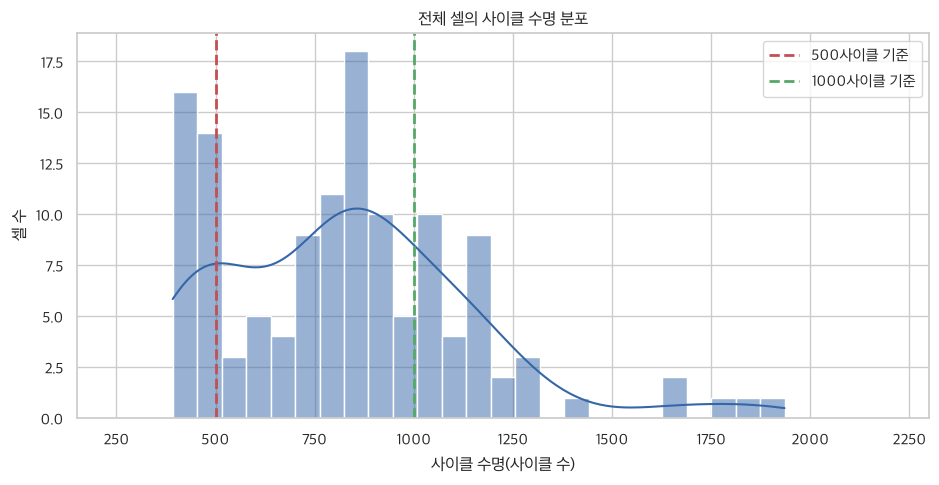

실제 cycle_life 범위: 392.0 ~ 1935.0


In [ ]:
life_bins = [-np.inf, 500, 1000, np.inf]
life_labels = ["Short", "Middle", "Long"]
cell_df["life_group"] = pd.cut(
    cell_df["cycle_life"], bins=life_bins, labels=life_labels, right=True, include_lowest=True
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(cell_df, x="cycle_life", bins=25, kde=True, ax=ax, color="#3567A8")
for value, color in [(500, "#C44E52"), (1000, "#55A868")]:
    ax.axvline(value, color=color, linestyle="--", linewidth=2, label=f"{value}사이클 기준")
ax.set_xlim(150, 2300)
ax.set_title("전체 셀의 사이클 수명 분포")
ax.set_xlabel("사이클 수명(사이클 수)")
ax.set_ylabel("셀 수")
ax.legend()
save_figure("cycle_life_distribution.png")
plt.show()

print("실제 cycle_life 범위:", cell_df["cycle_life"].min(), "~", cell_df["cycle_life"].max())


### 2-2. 수명 그룹 구성비

단수명·중수명·장수명 셀의 개수와 비율을 확인하고 배치별 구성 차이를 비교한다. 그룹 불균형이 크면 전체 평균이나 무작위 분할 결과가 특정 그룹에 치우칠 수 있다.


In [ ]:
group_count = cell_df["life_group"].value_counts(sort=False).rename("count").to_frame()
group_count["ratio_pct"] = group_count["count"] / len(cell_df) * 100
display(group_count)
print(f"cycle_life 결측으로 그룹 미분류: {cell_df['cycle_life'].isna().sum()}")

batch_group_count = pd.crosstab(cell_df["batch"], cell_df["life_group"])
batch_group_ratio = pd.crosstab(
    cell_df["batch"], cell_df["life_group"], normalize="index"
).mul(100)
print("[batch별 그룹 개수]")
display(batch_group_count)
print("[batch별 그룹 비율(%)]")
display(batch_group_ratio)


,count,ratio_pct
life_group,,
Short,28,19.8582
Middle,65,46.0993
Long,36,25.5319


cycle_life 결측으로 그룹 미분류: 12
[batch별 그룹 개수]


life_group,Short,Middle,Long
batch,,,
2017-05-12,0,36,10
2018-02-20,28,8,3
2018-04-12,0,21,23


[batch별 그룹 비율(%)]


life_group,Short,Middle,Long
batch,,,
2017-05-12,0.0000,78.2609,21.7391
2018-02-20,71.7949,20.5128,7.6923
2018-04-12,0.0000,47.7273,52.2727


### 2-3. 배치별 수명 분포

배치별 히스토그램으로 분포의 위치, 폭, 치우침을 비교한다. 세로 점선은 수명 그룹의 경계인 500·1,000사이클이며, 배치별 표본 수(`n`)도 제목에 함께 표시한다.


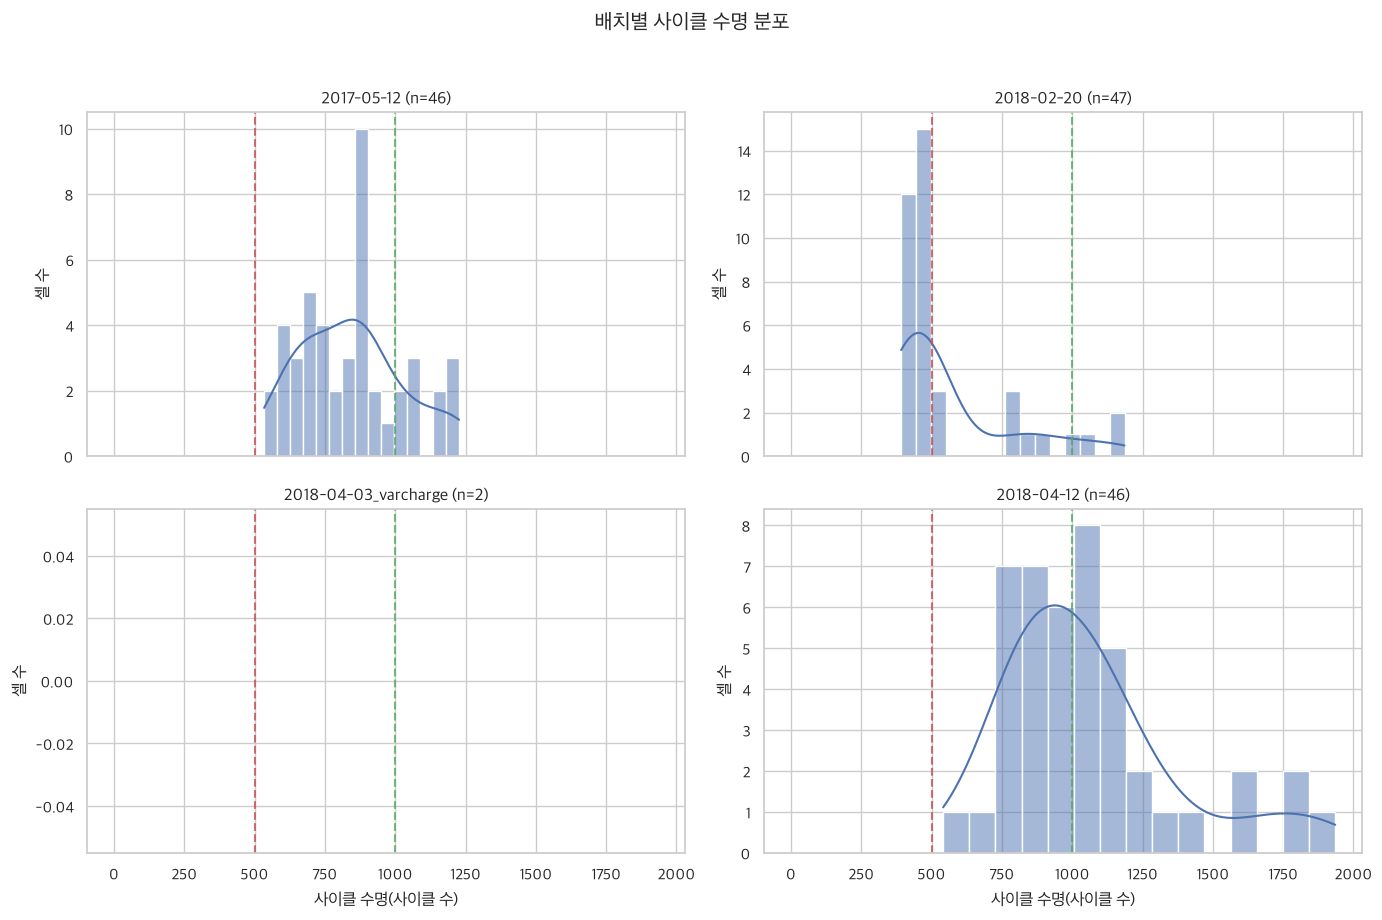

In [ ]:
batches = cell_df["batch"].drop_duplicates().tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, batch in zip(axes.flat, batches):
    subset = cell_df.loc[cell_df["batch"].eq(batch)]
    sns.histplot(subset, x="cycle_life", bins=15, kde=len(subset) > 2, ax=ax)
    ax.axvline(500, color="#C44E52", linestyle="--", alpha=0.8)
    ax.axvline(1000, color="#55A868", linestyle="--", alpha=0.8)
    ax.set_title(f"{batch} (n={len(subset)})")
    ax.set_xlabel("사이클 수명(사이클 수)")
    ax.set_ylabel("셀 수")
fig.suptitle("배치별 사이클 수명 분포", y=1.02, fontsize=15)
fig.tight_layout()
save_figure("cycle_life_by_batch_hist.png")
plt.show()


### 2-4. 배치 간 중앙값과 산포 비교

상자그림은 중앙값과 사분위 범위를, 점은 개별 셀을 나타낸다. 점을 함께 표시해 작은 표본에서 상자그림만으로 가려질 수 있는 군집과 극단값을 확인한다.


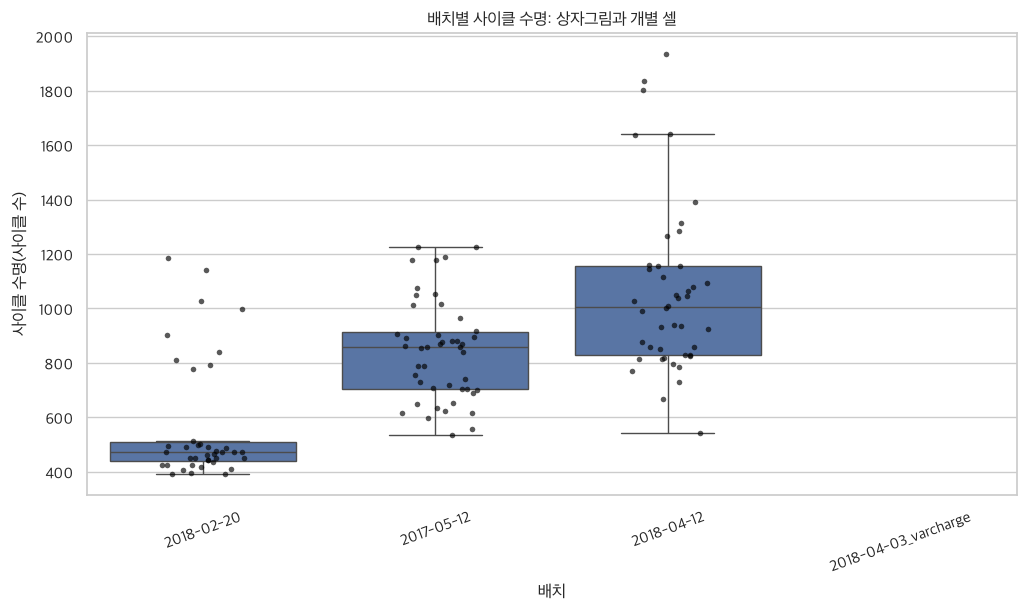

,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
2017-05-12,46.0000,844.7174,184.6292,534.0000,703.2500,858.5000,914.2500,"1,227.0000"
2018-02-20,39.0000,565.7436,222.2016,392.0000,439.5000,472.0000,508.5000,"1,186.0000"
2018-04-03_varcharge,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-12,44.0000,"1,059.6591",313.8697,541.0000,828.0000,"1,005.5000","1,155.2500","1,935.0000"


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
order = cell_df.groupby("batch")["cycle_life"].median().sort_values().index
sns.boxplot(data=cell_df, x="batch", y="cycle_life", order=order, showfliers=False, ax=ax)
sns.stripplot(
    data=cell_df, x="batch", y="cycle_life", order=order,
    color="black", alpha=0.65, jitter=0.18, size=4, ax=ax
)
ax.set_title("배치별 사이클 수명: 상자그림과 개별 셀")
ax.set_xlabel("배치")
ax.set_ylabel("사이클 수명(사이클 수)")
ax.tick_params(axis="x", rotation=20)
save_figure("cycle_life_by_batch_box.png")
plt.show()

display(cell_df.groupby("batch")["cycle_life"].describe())


### Batch별 IQR 이상치 후보

IQR 규칙은 분포에서 멀리 떨어진 관측치를 찾는 탐색 도구일 뿐 오류 판정이 아니다. 아래 셀들은 제거하지 않고 **실험 protocol, 센서 상태, 데이터 수집 이력의 후속 원인 분석 대상**으로 남긴다.

In [ ]:
def iqr_outlier_candidates(group):
    group = group.dropna(subset=["cycle_life"])
    if len(group) < 4:
        return pd.DataFrame(columns=[
            "cell_key", "batch", "cycle_life", "policy_readable",
            "iqr_lower", "iqr_upper", "status"
        ])
    q1 = group["cycle_life"].quantile(0.25)
    q3 = group["cycle_life"].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    result = group.loc[
        ~group["cycle_life"].between(lower, upper),
        ["cell_key", "batch", "cycle_life", "policy_readable"],
    ].copy()
    result["iqr_lower"] = lower
    result["iqr_upper"] = upper
    result["status"] = "후속 원인 분석 대상 (자동 제거 금지)"
    return result

candidate_frames = [
    iqr_outlier_candidates(group) for _, group in cell_df.groupby("batch")
]
candidate_frames = [frame for frame in candidate_frames if not frame.empty]
outlier_candidates = (
    pd.concat(candidate_frames, ignore_index=True)
    if candidate_frames
    else pd.DataFrame(columns=[
        "cell_key", "batch", "cycle_life", "policy_readable",
        "iqr_lower", "iqr_upper", "status"
    ])
)
display(outlier_candidates.sort_values(["batch", "cycle_life"]))


,cell_key,batch,cycle_life,policy_readable,iqr_lower,iqr_upper,status
0,2018-02-20_cell_8,2018-02-20,777.0000,4.8C(80%)-4.8C-newstructure,336.0000,612.0000,후속 원인 분석 대상 (자동 제거 금지)
2,2018-02-20_cell_10,2018-02-20,791.0000,5.6C(26%)-4.5C-newstructure,336.0000,612.0000,후속 원인 분석 대상 (자동 제거 금지)
3,2018-02-20_cell_33,2018-02-20,809.0000,4.8C(80%)-4.8C-newstructure,336.0000,612.0000,후속 원인 분석 대상 (자동 제거 금지)
7,2018-02-20_cell_45,2018-02-20,841.0000,5.2C(58%)-4C-newstructure,336.0000,612.0000,후속 원인 분석 대상 (자동 제거 금지)
1,2018-02-20_cell_9,2018-02-20,904.0000,5.2C(58%)-4C-newstructure,336.0000,612.0000,후속 원인 분석 대상 (자동 제거 금지)
8,2018-02-20_cell_46,2018-02-20,997.0000,5.6C(26%)-4.5C-newstructure,336.0000,612.0000,후속 원인 분석 대상 (자동 제거 금지)
6,2018-02-20_cell_44,2018-02-20,"1,029.0000",4.8C(80%)-4.8C-newstructure,336.0000,612.0000,후속 원인 분석 대상 (자동 제거 금지)
4,2018-02-20_cell_34,2018-02-20,"1,140.0000",5.2C(58%)-4C-newstructure,336.0000,612.0000,후속 원인 분석 대상 (자동 제거 금지)
5,2018-02-20_cell_35,2018-02-20,"1,186.0000",5.6C(26%)-4.5C-newstructure,336.0000,612.0000,후속 원인 분석 대상 (자동 제거 금지)
11,2018-04-12_cell_46,2018-04-12,"1,801.0000",4.8C(80%)-4.8C-newstructure,337.1250,"1,646.1250",후속 원인 분석 대상 (자동 제거 금지)


# 3. QDischarge 열화곡선

## 질문: 사이클이 증가함에 따라 방전 용량은 어떻게 감소하는가?

cycle 1의 placeholder 가능성이 높은 0값은 이 섹션의 곡선·slope 계산에서 제외한다. 원본 행은 `summary_df`에 그대로 유지한다. 대표 셀은 각 그룹의 수명 25%, 50%, 75% 분위수에 가장 가까운 셀을 선택해 임의 선택 편향을 줄인다.

### 3-1. 유효 곡선과 대표 셀 선정

사이클 1의 의심스러운 0값과 비양의 방전 용량을 곡선 분석에서 제외한다. 각 수명 그룹의 25·50·75% 분위수에 가장 가까운 셀을 대표로 선택해 임의 선택 편향을 줄인다.


In [ ]:
summary_life = summary_df.merge(
    cell_df[["cell_key", "cycle_life", "life_group", "policy_readable"]],
    on="cell_key", how="left", validate="many_to_one"
)
valid_q = summary_life.loc[
    summary_life["cycle"].gt(1) & summary_life["QDischarge"].gt(0)
].copy()

def representative_keys(frame, group_col, n=3):
    keys = []
    quantiles = np.linspace(0.25, 0.75, n)
    for label, group in frame.groupby(group_col, observed=True):
        group = group.dropna(subset=["cycle_life"])
        if group.empty:
            continue
        for q in quantiles:
            target = group["cycle_life"].quantile(q)
            idx = (group["cycle_life"] - target).abs().idxmin()
            keys.append(group.loc[idx, "cell_key"])
    return list(dict.fromkeys(keys))

representative_cells = representative_keys(cell_df, "life_group", n=3)
display(cell_df.loc[cell_df["cell_key"].isin(representative_cells),
                    ["cell_key", "batch", "cycle_life", "life_group"]]
        .sort_values(["life_group", "cycle_life"]))


,cell_key,batch,cycle_life,life_group
77,2018-02-20_cell_32,2018-02-20,425.0000,Short
57,2018-02-20_cell_12,2018-02-20,449.0000,Short
73,2018-02-20_cell_28,2018-02-20,474.0000,Short
36,2017-05-12_cell_37,2017-05-12,704.0000,Middle
108,2018-04-12_cell_14,2018-04-12,816.0000,Middle
31,2017-05-12_cell_32,2017-05-12,876.0000,Middle
41,2017-05-12_cell_42,2017-05-12,"1,051.0000",Long
113,2018-04-12_cell_19,2018-04-12,"1,146.0000",Long
4,2017-05-12_cell_5,2017-05-12,"1,227.0000",Long


### 3-2. 수명 그룹별 방전 용량 열화곡선

대표 셀의 실제 사이클에 따른 방전 용량 변화를 비교한다. 곡선의 하락 속도와 후반부 급격한 꺾임이 수명 그룹별로 어떻게 다른지 살펴본다.


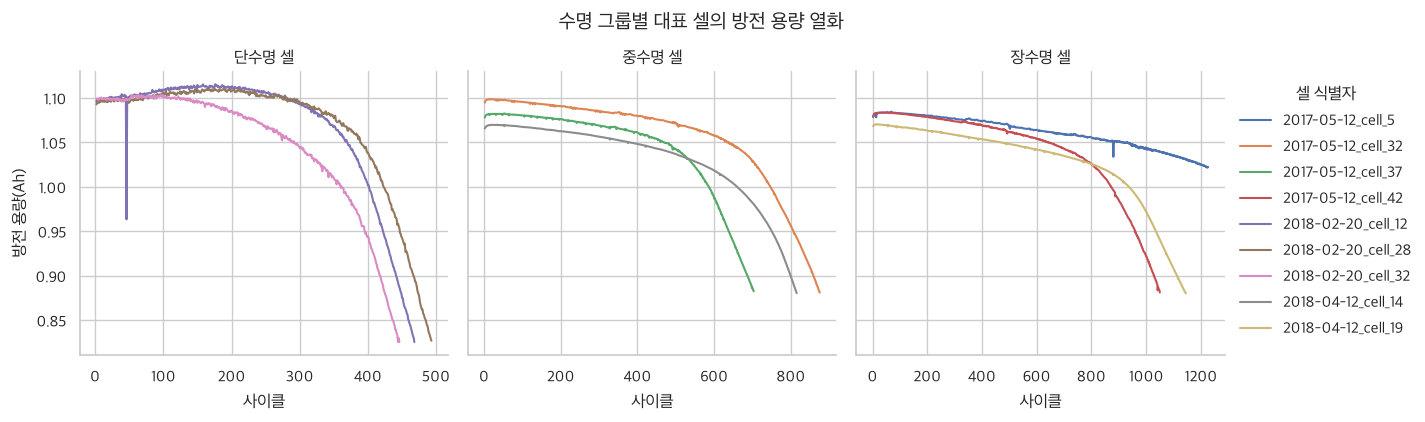

In [ ]:
plot_data = valid_q.loc[valid_q["cell_key"].isin(representative_cells)].copy()
plot_data["수명 그룹"] = plot_data["life_group"].map(LIFE_GROUP_KO)
g = sns.relplot(
    data=plot_data, x="cycle", y="QDischarge", hue="cell_key",
    col="수명 그룹", col_order=list(LIFE_GROUP_KO.values()), kind="line",
    height=4, aspect=1.05, facet_kws={"sharex": False, "sharey": True}
)
g.set_axis_labels("사이클", "방전 용량(Ah)")
g.set_titles("{col_name} 셀")
if g._legend is not None:
    g._legend.set_title("셀 식별자")
g.figure.suptitle("수명 그룹별 대표 셀의 방전 용량 열화", y=1.05)
if SAVE_FIGURES:
    g.savefig(FIGURE_DIR / "representative_degradation.png", dpi=150, bbox_inches="tight")
plt.show()


### 3-3. 수명 진행률 기준 열화곡선

셀마다 최종 수명이 다르므로 현재 사이클을 최종 수명으로 나눈 진행률로 가로축을 정규화한다. 절대 사이클 그래프와 함께 보면 열화가 수명 중 어느 시점부터 가속되는지 비교하기 쉽다.


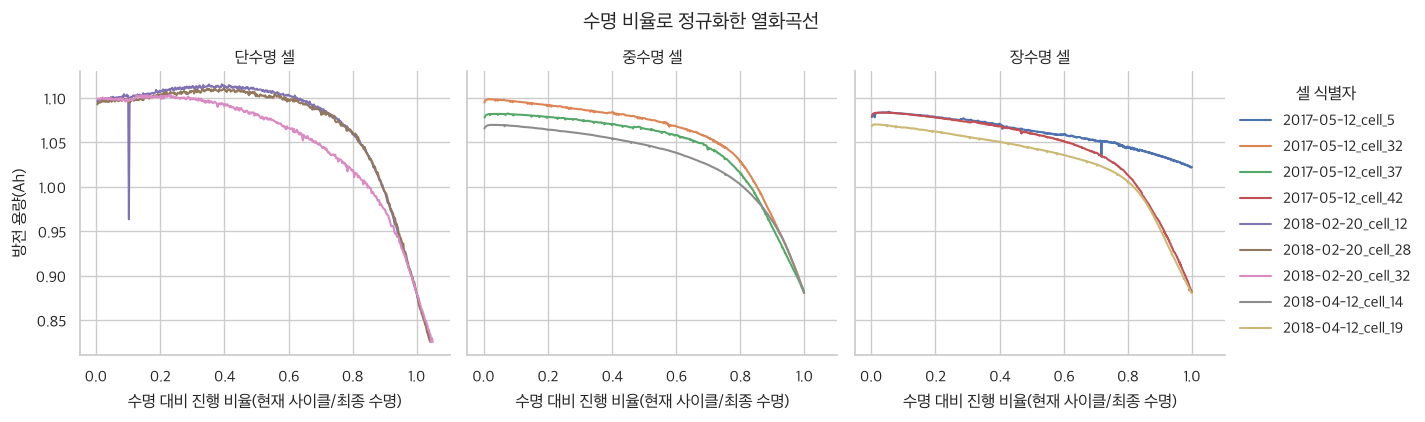

In [ ]:
normalized_q = plot_data.copy()  # plot_data의 한글 수명 그룹 열도 함께 유지한다.
normalized_q["life_fraction"] = normalized_q["cycle"] / normalized_q["cycle_life"]
normalized_q = normalized_q.loc[normalized_q["life_fraction"].between(0, 1.05)]

g = sns.relplot(
    data=normalized_q, x="life_fraction", y="QDischarge", hue="cell_key",
    col="수명 그룹", col_order=list(LIFE_GROUP_KO.values()), kind="line",
    height=4, aspect=1.05, facet_kws={"sharex": True, "sharey": True}
)
g.set_axis_labels("수명 대비 진행 비율(현재 사이클/최종 수명)", "방전 용량(Ah)")
g.set_titles("{col_name} 셀")
if g._legend is not None:
    g._legend.set_title("셀 식별자")
g.figure.suptitle("수명 비율로 정규화한 열화곡선", y=1.05)
plt.show()


### 3-4. 배치별 대표 열화곡선

각 배치에서 대표 셀을 선택해 측정 시기와 실험 조건에 따른 곡선 차이를 확인한다. 배치별 형태 차이가 크다면 모델이 배터리 열화가 아니라 배치 특성을 학습할 위험이 있다.


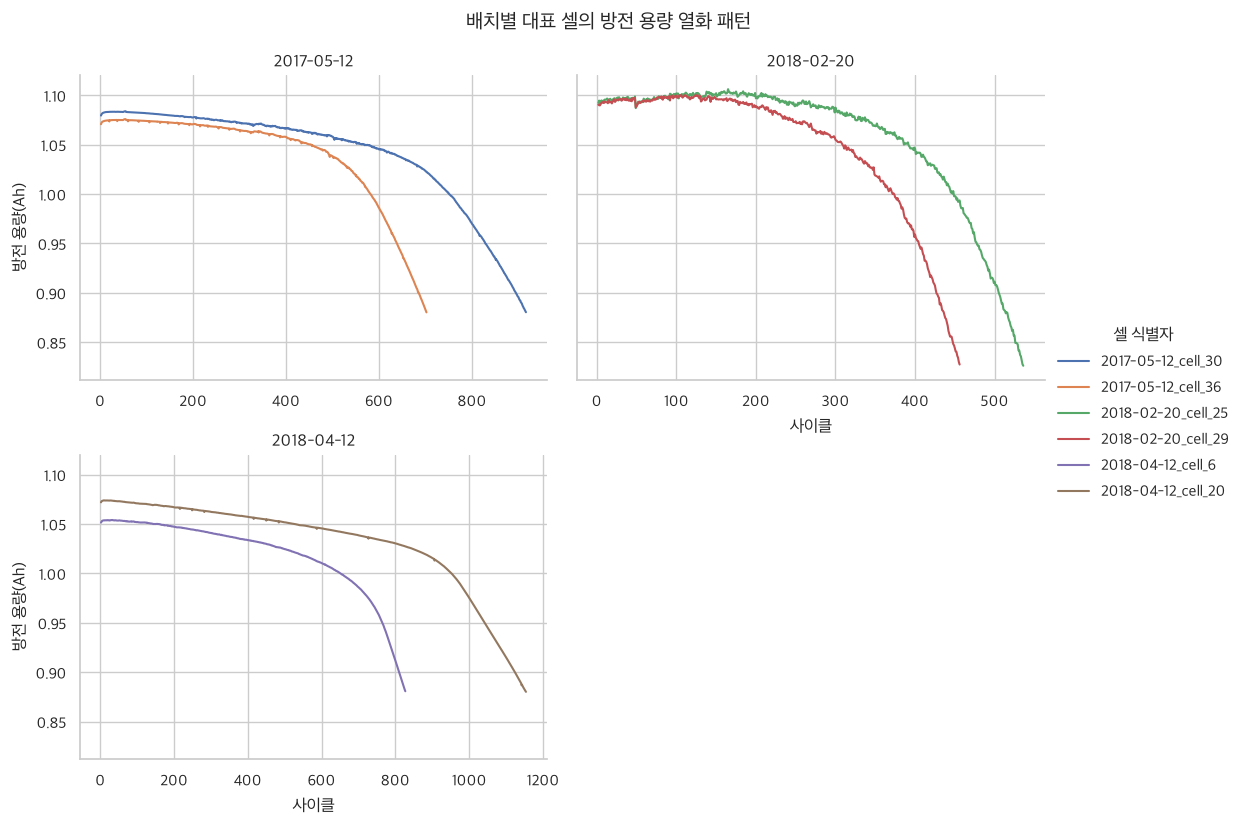

In [ ]:
batch_representatives = representative_keys(cell_df, "batch", n=2)
batch_plot = valid_q.loc[valid_q["cell_key"].isin(batch_representatives)]
g = sns.relplot(
    data=batch_plot, x="cycle", y="QDischarge", hue="cell_key",
    col="batch", col_wrap=2, kind="line", height=4, aspect=1.35,
    facet_kws={"sharex": False, "sharey": True}
)
g.set_axis_labels("사이클", "방전 용량(Ah)")
g.set_titles("{col_name}")
if g._legend is not None:
    g._legend.set_title("셀 식별자")
g.figure.suptitle("배치별 대표 셀의 방전 용량 열화 패턴", y=1.03)
plt.show()


### 초기 구간과 후기 구간의 slope

초기 slope는 cycle 2~100, 후기 slope는 각 셀의 마지막 100개 유효 관측치로 단순 선형 회귀한다. 서로 다른 구간 길이와 noise가 있으므로 절대적 물리계수보다 EDA 비교 지표로 해석한다.

life_group                     Short  Middle    Long
early_q_slope          count 28.0000 65.0000 36.0000
                       mean   0.0000 -0.0000 -0.0000
                       std    0.0001  0.0001  0.0000
                       min   -0.0002 -0.0003 -0.0002
                       25%   -0.0000 -0.0000 -0.0000
                       50%    0.0000 -0.0000 -0.0000
                       75%    0.0001  0.0000  0.0000
                       max    0.0001  0.0001  0.0000
late_q_slope           count 28.0000 65.0000 36.0000
                       mean  -0.0020 -0.0010 -0.0007
                       std    0.0002  0.0003  0.0003
                       min   -0.0024 -0.0019 -0.0013
                       25%   -0.0021 -0.0011 -0.0008
                       50%   -0.0019 -0.0010 -0.0007
                       75%   -0.0018 -0.0009 -0.0005
                       max   -0.0015 -0.0005 -0.0000
late_minus_early_slope count 28.0000 65.0000 36.0000
                       mean  -0.0020 -0.0010 -0.0007
                       std    0.0003  0.0003  0.0003
                       min   -0.0025 -0.0019 -0.0012
                       25%   -0.0022 -0.0011 -0.0008
                       50%   -0.0020 -0.0010 -0.0007
                       75%   -0.0018 -0.0009 -0.0005
                       max   -0.0013 -0.0003  0.0001

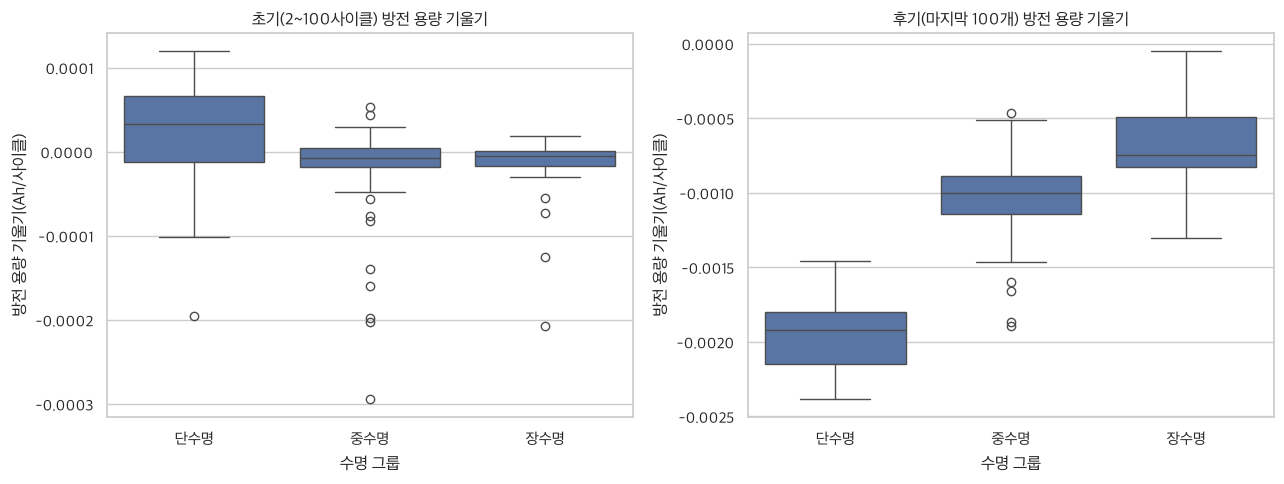

In [ ]:
def linear_slope(frame, x="cycle", y="QDischarge"):
    clean = frame[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean) < 2 or clean[x].nunique() < 2:
        return np.nan
    return np.polyfit(clean[x], clean[y], 1)[0]

slope_rows = []
for cell_key, group in valid_q.groupby("cell_key"):
    ordered = group.sort_values("cycle")
    early = ordered.loc[ordered["cycle"].le(100)]
    late = ordered.tail(100)
    slope_rows.append({
        "cell_key": cell_key,
        "early_q_slope": linear_slope(early),
        "late_q_slope": linear_slope(late),
    })

slope_df = pd.DataFrame(slope_rows).merge(
    cell_df[["cell_key", "batch", "cycle_life", "life_group"]], on="cell_key"
)
slope_df["late_minus_early_slope"] = slope_df["late_q_slope"] - slope_df["early_q_slope"]
display(slope_df.groupby("life_group", observed=True)[
    ["early_q_slope", "late_q_slope", "late_minus_early_slope"]
].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
slope_plot_df = slope_df.assign(수명그룹=slope_df["life_group"].map(LIFE_GROUP_KO))
sns.boxplot(data=slope_plot_df, x="수명그룹", y="early_q_slope", order=list(LIFE_GROUP_KO.values()), ax=axes[0])
sns.boxplot(data=slope_plot_df, x="수명그룹", y="late_q_slope", order=list(LIFE_GROUP_KO.values()), ax=axes[1])
axes[0].set_title("초기(2~100사이클) 방전 용량 기울기")
axes[1].set_title("후기(마지막 100개) 방전 용량 기울기")
for ax in axes:
    ax.set_xlabel("수명 그룹")
    ax.set_ylabel("방전 용량 기울기(Ah/사이클)")
plt.tight_layout()
plt.show()


### EDA용 Knee point 탐색

방전 용량을 rolling median으로 완화한 뒤 후보 breakpoint 앞·뒤에 각각 직선을 적합한다. 두 구간 잔차제곱합(SSE)이 가장 작은 지점을 knee 후보로 둔다. 이는 설명 가능한 간단한 근사이며 정교한 물리 기반 knee 검출기는 아니다.

> **Leakage 주의:** knee point는 셀의 전체 수명 구간을 사용한다. 따라서 “초기 100 cycle 기반 수명 예측”의 입력 feature로 직접 사용하면 미래 정보 leakage가 발생한다. 아래 결과는 열화 형태를 이해하는 EDA에만 사용한다.

In [ ]:
def estimate_knee(group, smooth_window=21, n_candidates=60):
    clean = group.loc[group["QDischarge"].gt(0), ["cycle", "QDischarge"]].dropna().sort_values("cycle")
    if len(clean) < 60:
        return pd.Series({"knee_cycle": np.nan, "knee_sse": np.nan})
    x = clean["cycle"].to_numpy(float)
    y = clean["QDischarge"].rolling(smooth_window, center=True, min_periods=3).median().to_numpy(float)
    lo, hi = max(15, int(len(x) * 0.20)), min(len(x) - 15, int(len(x) * 0.85))
    candidates = np.unique(np.linspace(lo, hi, n_candidates).astype(int))
    best = (np.inf, None)
    for bp in candidates:
        left_fit = np.polyval(np.polyfit(x[:bp], y[:bp], 1), x[:bp])
        right_fit = np.polyval(np.polyfit(x[bp:], y[bp:], 1), x[bp:])
        sse = np.square(y[:bp] - left_fit).sum() + np.square(y[bp:] - right_fit).sum()
        if sse < best[0]:
            best = (sse, bp)
    return pd.Series({"knee_cycle": x[best[1]], "knee_sse": best[0]})

knee_df = (
    valid_q.groupby("cell_key", group_keys=False)[["cycle", "QDischarge"]]
    .apply(estimate_knee)
    .reset_index()
    .merge(cell_df[["cell_key", "batch", "cycle_life", "life_group"]], on="cell_key")
)
knee_df["knee_life_fraction"] = knee_df["knee_cycle"] / knee_df["cycle_life"]
display(knee_df.groupby("life_group", observed=True)[["knee_cycle", "knee_life_fraction"]].describe())


knee_cycle                                                        \
                count     mean      std      min      25%      50%      75%   
life_group                                                                    
Short         28.0000 345.3571  29.7648 285.0000 330.2500 347.5000 362.5000   
Middle        65.0000 607.3538 105.6170 376.0000 547.0000 632.0000 676.0000   
Long          36.0000 926.9167 242.8744 418.0000 826.5000 885.5000 984.7500   

                      knee_life_fraction                                     \
                  max              count   mean    std    min    25%    50%   
life_group                                                                    
Short        395.0000            28.0000 0.7688 0.0292 0.7091 0.7504 0.7711   
Middle       818.0000            65.0000 0.7700 0.0371 0.6948 0.7398 0.7720   
Long       1,517.0000            36.0000 0.7612 0.1196 0.3545 0.7723 0.7890   

                          
              75%    max  
life_group                
Short      0.7903 0.8349  
Middle     0.7941 0.8494  
Long       0.8158 0.8503

### 3-7. 대표 셀의 전환점 시각 확인

평활화한 방전 용량 곡선 위에 계산된 knee cycle을 세로 점선으로 표시한다. 자동 탐지 결과가 실제로 급격한 열화가 시작되는 위치와 대체로 일치하는지 시각적으로 검토한다.


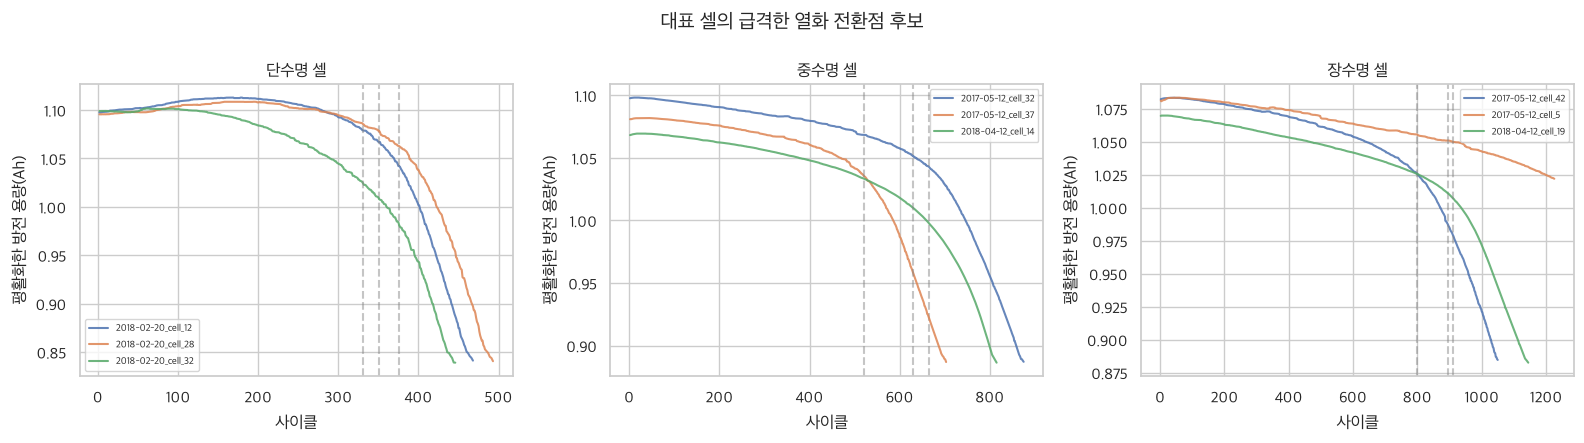

In [ ]:
knee_examples = knee_df.loc[knee_df["cell_key"].isin(representative_cells)]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, life_group in zip(axes, life_labels):
    keys = knee_examples.loc[knee_examples["life_group"].eq(life_group), "cell_key"]
    for key in keys:
        curve = valid_q.loc[valid_q["cell_key"].eq(key)].sort_values("cycle")
        smooth = curve["QDischarge"].rolling(21, center=True, min_periods=3).median()
        ax.plot(curve["cycle"], smooth, label=key, alpha=0.85)
        knee = knee_examples.loc[knee_examples["cell_key"].eq(key), "knee_cycle"].iloc[0]
        ax.axvline(knee, color="gray", linestyle="--", alpha=0.45)
    ax.set_title(f"{LIFE_GROUP_KO[life_group]} 셀")
    ax.set_xlabel("사이클")
    ax.set_ylabel("평활화한 방전 용량(Ah)")
    ax.legend(fontsize=7)
fig.suptitle("대표 셀의 급격한 열화 전환점 후보")
plt.tight_layout()
plt.show()


# 4. ΔQ(V) 분석

## 질문: 초기 cycle에서 장수명 셀과 단수명 셀의 차이가 보이는가?

`src.preprocess.load_delta_q()`는 MAT 전체 시계열을 DataFrame으로 만들지 않고, 지정 cell의 `Vdlin`과 cycle 10/100의 `Qdlin`만 HDF5에서 읽는다.

\[
\Delta Q(V) = Q_{100}(V) - Q_{10}(V)
\]

먼저 Short/Long에서 각 3개 대표 셀을 비교한다. 이어서 모델 feature 테이블을 위해 전체 셀에 같은 연산을 적용한다.

### 4-1. ΔQ(V) 비교용 대표 셀 선정

단수명과 장수명 그룹에서 수명 순서상 고르게 최대 3개 셀을 선택한다. 중수명 그룹은 양 끝 그룹의 차이를 선명하게 탐색하려는 이번 비교에서 제외한다.


In [ ]:
delta_sample_cells = []
for group_name in ["Short", "Long"]:
    group = cell_df.loc[cell_df["life_group"].eq(group_name)].sort_values("cycle_life")
    if len(group):
        positions = np.unique(np.linspace(0, len(group) - 1, min(3, len(group))).astype(int))
        delta_sample_cells.extend(group.iloc[positions]["cell_key"].tolist())

display(cell_df.loc[cell_df["cell_key"].isin(delta_sample_cells),
                    ["cell_key", "batch", "cell_index", "cycle_life", "life_group"]])


,cell_key,batch,cell_index,cycle_life,life_group
49,2018-02-20_cell_4,2018-02-20,3,499.0000,Short
64,2018-02-20_cell_19,2018-02-20,18,449.0000,Short
65,2018-02-20_cell_20,2018-02-20,19,392.0000,Short
113,2018-04-12_cell_19,2018-04-12,18,"1,146.0000",Long
117,2018-04-12_cell_23,2018-04-12,22,"1,002.0000",Long
133,2018-04-12_cell_39,2018-04-12,38,"1,935.0000",Long


### 4-2. 대표 셀별 ΔQ(V) 곡선

10사이클 대비 100사이클의 방전 용량 변화를 전압 구간별로 그린다. 곡선의 크기와 특정 전압대의 패턴이 단수명·장수명 셀을 구분하는지 확인한다.


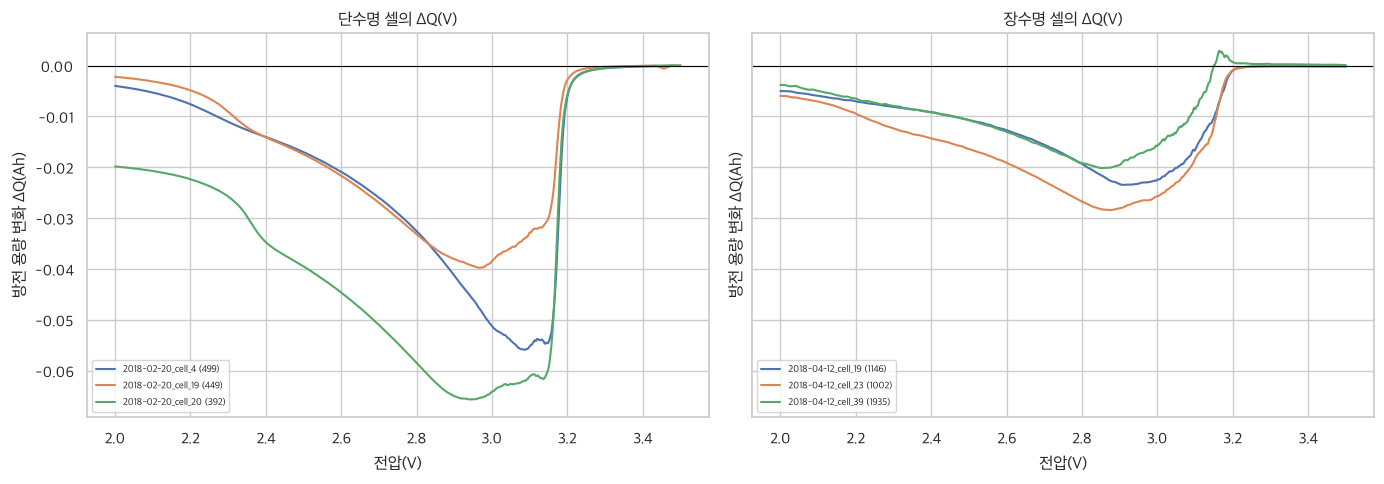

In [ ]:
delta_curve_cache = {}

def get_delta_curve(row):
    key = row["cell_key"]
    if key not in delta_curve_cache:
        delta_curve_cache[key] = load_delta_q(
            DATA_FILES[row["batch"]], int(row["cell_index"]), cycle_a=10, cycle_b=100
        )
    return delta_curve_cache[key]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, group_name in zip(axes, ["Short", "Long"]):
    rows = cell_df.loc[
        cell_df["cell_key"].isin(delta_sample_cells) & cell_df["life_group"].eq(group_name)
    ]
    for _, row in rows.iterrows():
        dq = get_delta_curve(row)
        ax.plot(dq["V"], dq["delta_Q"], label=f"{row['cell_key']} ({row['cycle_life']:.0f})")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{LIFE_GROUP_KO[group_name]} 셀의 ΔQ(V)")
    ax.set_xlabel("전압(V)")
    ax.set_ylabel("방전 용량 변화 ΔQ(Ah)")
    ax.legend(fontsize=7)
plt.tight_layout()
save_figure("delta_q_short_long.png")
plt.show()


### 4-3. 수명 그룹 평균 ΔQ(V)

셀마다 전압 측정 지점이 다를 수 있어 공통 전압축으로 선형 보간한 뒤 그룹 평균을 계산한다. 대표 셀 수가 적으므로 평균 곡선은 경향 탐색용이며 모집단 차이로 단정하지 않는다.


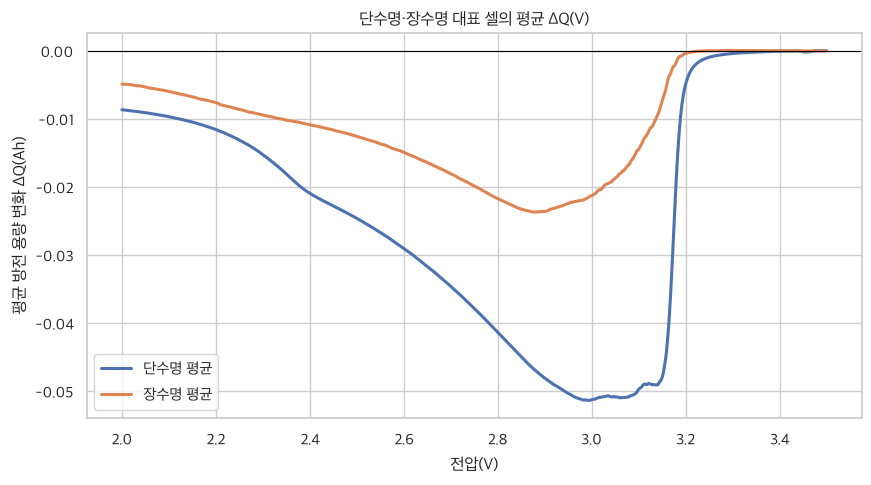

In [ ]:
common_voltage = np.linspace(2.0, 3.5, 1000)
group_mean_curves = {}
for group_name in ["Short", "Long"]:
    interpolated = []
    rows = cell_df.loc[
        cell_df["cell_key"].isin(delta_sample_cells) & cell_df["life_group"].eq(group_name)
    ]
    for _, row in rows.iterrows():
        dq = get_delta_curve(row).sort_values("V")
        interpolated.append(np.interp(common_voltage, dq["V"], dq["delta_Q"]))
    if interpolated:
        group_mean_curves[group_name] = np.vstack(interpolated).mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
for group_name, mean_curve in group_mean_curves.items():
    ax.plot(common_voltage, mean_curve, linewidth=2.2, label=f"{LIFE_GROUP_KO[group_name]} 평균")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("단수명·장수명 대표 셀의 평균 ΔQ(V)")
ax.set_xlabel("전압(V)")
ax.set_ylabel("평균 방전 용량 변화 ΔQ(Ah)")
ax.legend()
plt.show()


### ΔQ(V) 통계 feature

아래 함수는 한 셀의 ΔQ 곡선에서 mean, std, variance, min, max, range, skewness, kurtosis를 계산한다. 전체 141개 셀을 순회하지만 각 파일에서 두 cycle의 Qdlin만 선택적으로 읽는다. 오류가 있는 셀은 분석을 중단하지 않고 상태 테이블에 남긴다.

In [ ]:
def delta_q_statistics(values):
    x = pd.Series(values, dtype=float).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if len(x) < 4:
        return {name: np.nan for name in [
            "dq_mean", "dq_std", "dq_variance", "dq_min", "dq_max",
            "dq_range", "dq_skewness", "dq_kurtosis"
        ]}
    return {
        "dq_mean": x.mean(),
        "dq_std": x.std(ddof=1),
        "dq_variance": x.var(ddof=1),
        "dq_min": x.min(),
        "dq_max": x.max(),
        "dq_range": x.max() - x.min(),
        "dq_skewness": skew(x, bias=False),
        "dq_kurtosis": kurtosis(x, fisher=True, bias=False),
    }

delta_feature_rows, delta_errors = [], []
for _, row in cell_df.iterrows():
    try:
        dq = get_delta_curve(row)
        delta_feature_rows.append({"cell_key": row["cell_key"], **delta_q_statistics(dq["delta_Q"])})
    except Exception as exc:
        delta_errors.append({"cell_key": row["cell_key"], "error": repr(exc)})

delta_feature_df = pd.DataFrame(delta_feature_rows)
delta_error_df = pd.DataFrame(delta_errors, columns=["cell_key", "error"])
print("ΔQ feature 성공:", len(delta_feature_df), "/", len(cell_df))
display(delta_feature_df.head())
display(delta_error_df)


ΔQ feature 성공: 141 / 141


,cell_key,dq_mean,dq_std,dq_variance,dq_min,dq_max,dq_range,dq_skewness,dq_kurtosis
0,2017-05-12_cell_1,-0.0029,0.0031,0.0000,-0.0085,0.0008,0.0092,-0.5329,-1.3491
1,2017-05-12_cell_2,-0.0041,0.0031,0.0000,-0.0110,-0.0001,0.0109,-0.4300,-1.0283
2,2017-05-12_cell_3,-0.0045,0.0043,0.0000,-0.0172,0.0000,0.0172,-1.0818,0.3564
3,2017-05-12_cell_4,-0.0075,0.0060,0.0000,-0.0190,0.0002,0.0191,-0.4397,-1.0949
4,2017-05-12_cell_5,-0.0058,0.0047,0.0000,-0.0140,0.0000,0.0140,-0.3631,-1.3345


,cell_key,error


# 5. 충전 조건과 수명의 관계

`policy_readable` 문자열에서 등장 순서상 첫 C-rate와 모든 C-rate 중 최댓값을 추출한다. protocol에는 C-rate 외에도 전환 SOC, slow-cycle, cell structure, batch 조건이 함께 들어 있으므로 **고속 충전이 반드시 수명을 감소시킨다고 단정하지 않는다**. 아래 결과는 상관관계이며 protocol의 복합 효과와 batch confounding을 분리해 해석해야 한다.

### 5-1. 충전 프로토콜별 수명 요약

동일한 프로토콜을 적용한 셀의 개수, 평균·중앙 수명, 표준편차와 범위를 계산한다. 표본 수가 작은 프로토콜의 평균은 변동성이 클 수 있으므로 셀 수와 함께 해석한다.


In [ ]:
protocol_summary = (
    cell_df.groupby("policy_readable", dropna=False)["cycle_life"]
    .agg(cell_count="size", mean_cycle_life="mean", median_cycle_life="median",
         std_cycle_life="std", min_cycle_life="min", max_cycle_life="max")
    .sort_values(["mean_cycle_life", "cell_count"], ascending=[False, False])
)
display(protocol_summary)


,cell_count,mean_cycle_life,median_cycle_life,std_cycle_life,min_cycle_life,max_cycle_life
policy_readable,,,,,,
4.8C(80%)-4.8C-newstructure,11,"1,333.3333","1,390.0000",419.0674,777.0000,"1,836.0000"
4C(80%)-4C,2,"1,226.5000","1,226.5000",0.7071,"1,226.0000","1,227.0000"
3.6C(80%)-3.6C,3,"1,182.0000","1,179.0000",7.0000,"1,177.0000","1,190.0000"
5C(67%)-4C-newstructure,7,"1,105.7143","1,009.0000",402.9118,813.0000,"1,935.0000"
5.3C(54%)-4C-newstructure,8,"1,074.3750","1,051.0000",129.6742,935.0000,"1,315.0000"
4.4C(80%)-4.4C,1,"1,074.0000","1,074.0000",NaN,"1,074.0000","1,074.0000"
8C(15%)-3.6C,2,"1,008.5000","1,008.5000",60.1041,966.0000,"1,051.0000"
5.6C(19%)-4.6C-newstructure,8,"1,001.3750","1,038.0000",174.5557,796.0000,"1,267.0000"
5.6C(26%)-4.5C-newstructure,3,991.3333,997.0000,197.5610,791.0000,"1,186.0000"


### 5-2. 프로토콜별 수명 분포

프로토콜별 중앙값 순서로 상자그림과 개별 셀을 표시한다. 프로토콜 문자열 전체가 여러 실험 조건의 조합이므로 단일 C-rate 효과와 동일하게 해석하지 않는다.


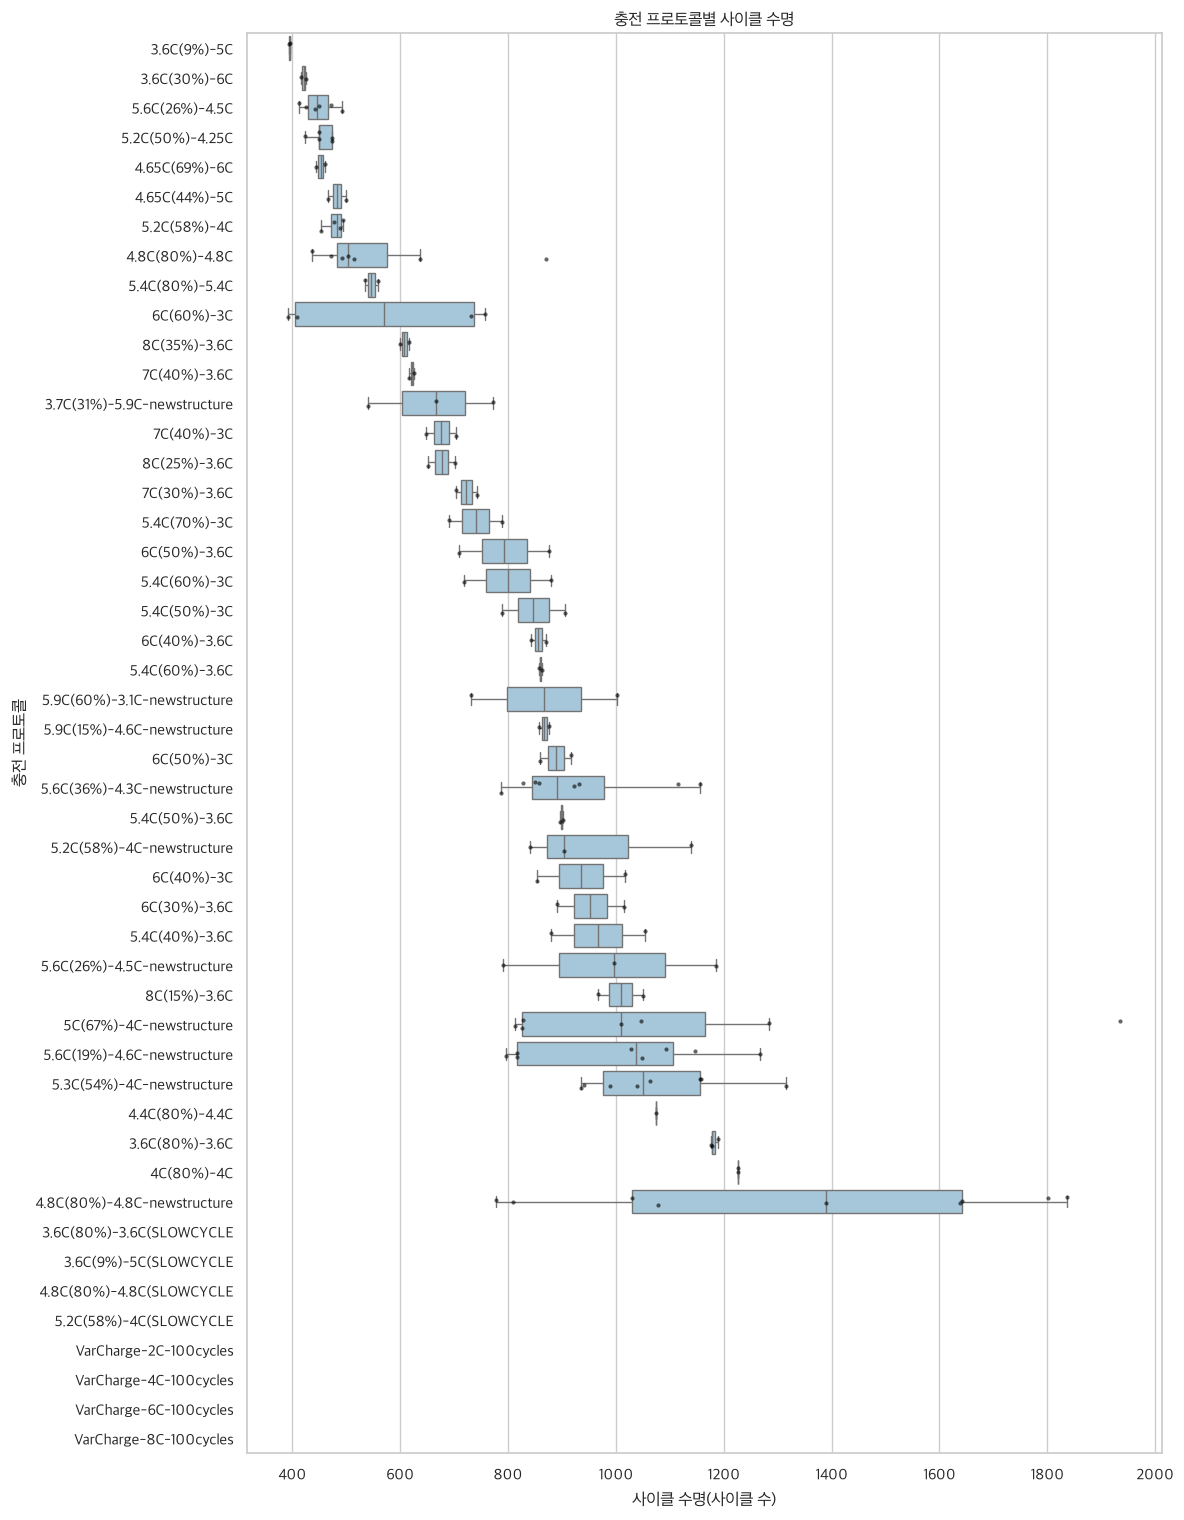

In [ ]:
protocol_order = (
    cell_df.groupby("policy_readable")["cycle_life"].median().sort_values().index
)
fig, ax = plt.subplots(figsize=(12, max(8, 0.32 * len(protocol_order))))
sns.boxplot(
    data=cell_df, y="policy_readable", x="cycle_life", order=protocol_order,
    showfliers=False, color="#9ECAE1", ax=ax
)
sns.stripplot(
    data=cell_df, y="policy_readable", x="cycle_life", order=protocol_order,
    color="black", alpha=0.6, size=3, jitter=0.18, ax=ax
)
ax.set_title("충전 프로토콜별 사이클 수명")
ax.set_xlabel("사이클 수명(사이클 수)")
ax.set_ylabel("충전 프로토콜")
plt.tight_layout()
plt.show()


### 5-3. 프로토콜에서 C-rate 추출

문자열에서 처음 등장하는 충전율과 전체 구간 중 최대 충전율을 숫자형 특성으로 추출한다. 파싱 결과의 고유 조합을 출력해 문자열 해석이 의도대로 되었는지 확인한다.


In [ ]:
def extract_c_rates(policy):
    rates = [float(value) for value in re.findall(r"(\d+(?:\.\d+)?)C", str(policy))]
    return pd.Series({
        "first_stage_c_rate": rates[0] if rates else np.nan,
        "max_c_rate": max(rates) if rates else np.nan,
    })

c_rate_df = cell_df["policy_readable"].apply(extract_c_rates)
cell_df = pd.concat([cell_df, c_rate_df], axis=1)
display(cell_df[["policy_readable", "first_stage_c_rate", "max_c_rate"]].drop_duplicates())


,policy_readable,first_stage_c_rate,max_c_rate
0,3.6C(80%)-3.6C,3.6000,3.6000
3,4C(80%)-4C,4.0000,4.0000
5,4.4C(80%)-4.4C,4.4000,4.4000
6,4.8C(80%)-4.8C,4.8000,4.8000
8,5.4C(40%)-3.6C,5.4000,5.4000
10,5.4C(50%)-3C,5.4000,5.4000
12,5.4C(50%)-3.6C,5.4000,5.4000
14,5.4C(60%)-3C,5.4000,5.4000
16,5.4C(60%)-3.6C,5.4000,5.4000
18,5.4C(70%)-3C,5.4000,5.4000


### 5-4. 충전율과 수명의 관계

산점도는 배치별 관측을 구분하고, 배치별 회귀선은 선형 경향을 탐색하는 참고선으로만 사용한다. 배치와 프로토콜이 얽혀 있으므로 기울기를 충전율의 인과 효과로 해석하지 않는다.


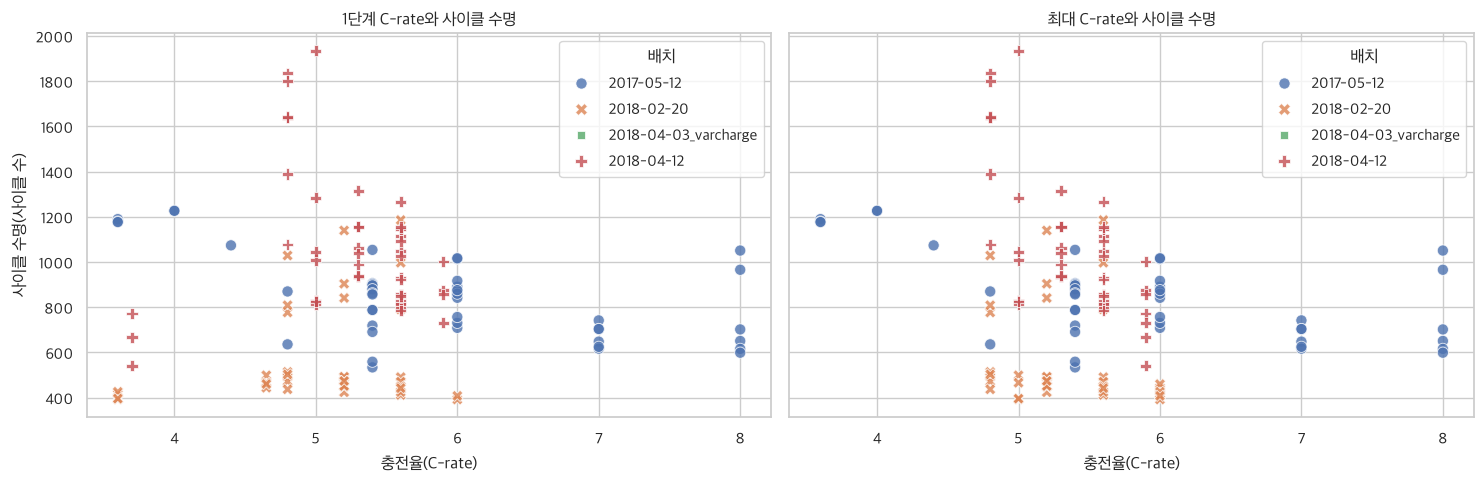

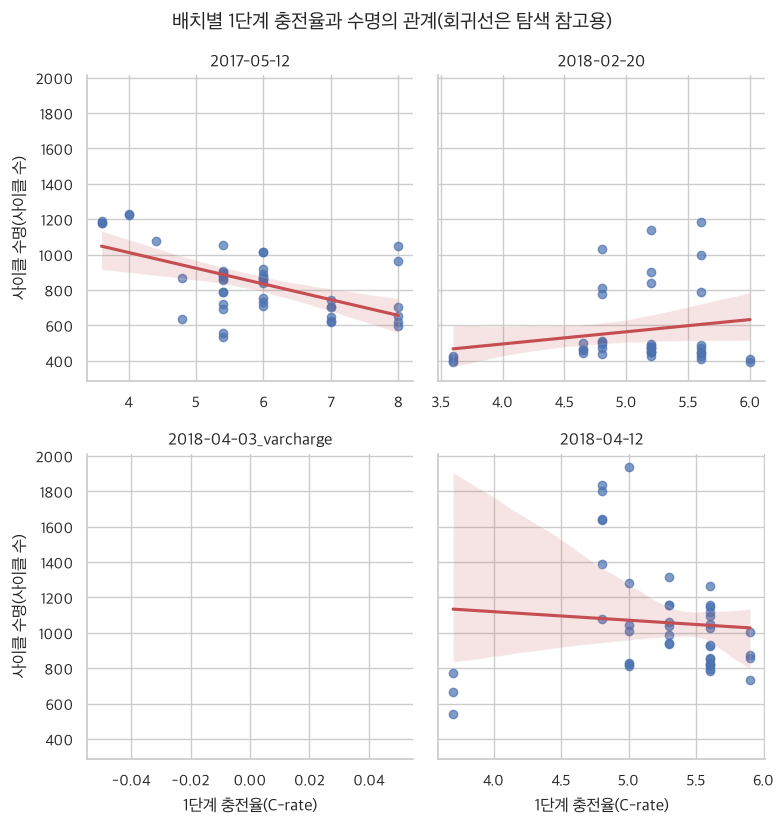

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.scatterplot(
    data=cell_df, x="first_stage_c_rate", y="cycle_life", hue="batch",
    style="batch", s=65, alpha=0.8, ax=axes[0]
)
sns.scatterplot(
    data=cell_df, x="max_c_rate", y="cycle_life", hue="batch",
    style="batch", s=65, alpha=0.8, ax=axes[1]
)
axes[0].set_title("1단계 C-rate와 사이클 수명")
axes[1].set_title("최대 C-rate와 사이클 수명")
for ax in axes:
    ax.set_xlabel("충전율(C-rate)")
    ax.set_ylabel("사이클 수명(사이클 수)")
    ax.legend(title="배치")
plt.tight_layout()
plt.show()

g = sns.lmplot(
    data=cell_df, x="first_stage_c_rate", y="cycle_life", col="batch", col_wrap=2,
    height=4, scatter_kws={"alpha": 0.7}, line_kws={"color": "#C44E52"},
    facet_kws={"sharex": False, "sharey": True}
)
g.set_axis_labels("1단계 충전율(C-rate)", "사이클 수명(사이클 수)")
g.set_titles("{col_name}")
g.figure.suptitle("배치별 1단계 충전율과 수명의 관계(회귀선은 탐색 참고용)", y=1.03)
plt.show()


# 6. 초기 100 cycle 기반 Feature Engineering

모델 입력 후보는 **cycle 1~100 안의 정보만** 사용한다. cycle 1 측정치가 placeholder일 가능성이 강하므로 원본을 삭제하지는 않되 집계에서는 `cycle > 1`이며 유효한 값을 사용한다. Target은 최종 `cycle_life`이다.

- `initial_QDischarge`: 첫 100 cycle 내 첫 양의 방전 용량
- mean/std/slope 및 cycle100-cycle10
- IR, Tmax, Tavg, chargetime 집계와 slope
- ΔQ(V) 통계와 protocol에서 파생한 C-rate

Knee point 및 마지막 100 cycle slope는 미래 정보를 사용하므로 이 테이블에 포함하지 않는다.

### 6-1. 초기 100사이클 특성 집계

각 셀의 2~100사이클에서 방전 용량, 내부저항, 온도, 충전시간의 평균·변동·기울기를 계산한다. 10→100사이클 변화량은 초기 열화 정도를 직접 나타내는 후보 특성이다.


In [ ]:
early = summary_df.loc[summary_df["cycle"].between(2, 100)].copy()

def first_positive(series):
    positive = series.loc[series.gt(0)].dropna()
    return positive.iloc[0] if len(positive) else np.nan

def value_at_cycle(group, cycle_number, column):
    values = group.loc[group["cycle"].eq(cycle_number), column].dropna()
    return values.iloc[0] if len(values) else np.nan

def safe_slope(group, column):
    clean = group[["cycle", column]].replace([np.inf, -np.inf], np.nan).dropna()
    if column in measurement_cols:
        clean = clean.loc[clean[column].ne(0)]
    if len(clean) < 2 or clean["cycle"].nunique() < 2:
        return np.nan
    return np.polyfit(clean["cycle"], clean[column], 1)[0]

early_rows = []
for cell_key, group in early.groupby("cell_key"):
    q10 = value_at_cycle(group, 10, "QDischarge")
    q100 = value_at_cycle(group, 100, "QDischarge")
    early_rows.append({
        "cell_key": cell_key,
        "initial_QDischarge": first_positive(group.sort_values("cycle")["QDischarge"]),
        "QDischarge_mean_100": group.loc[group["QDischarge"].gt(0), "QDischarge"].mean(),
        "QDischarge_std_100": group.loc[group["QDischarge"].gt(0), "QDischarge"].std(),
        "QDischarge_slope_100": safe_slope(group, "QDischarge"),
        "QDischarge_cycle100_minus_cycle10": q100 - q10,
        "IR_mean_100": group.loc[group["IR"].gt(0), "IR"].mean(),
        "IR_slope_100": safe_slope(group, "IR"),
        "Tmax_mean_100": group.loc[group["Tmax"].ne(0), "Tmax"].mean(),
        "Tavg_mean_100": group.loc[group["Tavg"].ne(0), "Tavg"].mean(),
        "temperature_slope_100": safe_slope(group, "Tavg"),
        "chargetime_mean_100": group.loc[group["chargetime"].gt(0), "chargetime"].mean(),
        "chargetime_slope_100": safe_slope(group, "chargetime"),
    })

early_feature_df = pd.DataFrame(early_rows)
display(early_feature_df.head())


,cell_key,initial_QDischarge,QDischarge_mean_100,QDischarge_std_100,QDischarge_slope_100,QDischarge_cycle100_minus_cycle10,IR_mean_100,IR_slope_100,Tmax_mean_100,Tavg_mean_100,temperature_slope_100,chargetime_mean_100,chargetime_slope_100
0,2017-05-12_cell_1,1.0707,1.0806,0.0466,-0.0002,0.0014,0.0166,-0.0000,35.3767,31.6037,-0.0012,13.3842,-0.0001
1,2017-05-12_cell_10,1.0830,1.0877,0.0010,0.0000,0.0010,0.0168,0.0000,35.9849,32.6415,0.0008,11.2419,0.0003
2,2017-05-12_cell_11,1.0753,1.0817,0.0016,0.0000,0.0021,0.0166,0.0000,36.8715,33.2082,-0.0006,11.6880,-0.0002
3,2017-05-12_cell_12,1.0538,1.0601,0.0014,0.0000,0.0019,0.0162,-0.0000,36.2318,32.7593,-0.0005,11.6841,0.0002
4,2017-05-12_cell_13,1.0776,1.0822,0.0009,0.0000,0.0008,0.0164,0.0000,37.4488,33.4580,0.0013,10.6839,-0.0001


### 6-2. 셀 단위 모델 입력표 결합

기본 셀 정보, 초기 구간 집계, ΔQ(V) 통계를 `cell_key` 기준으로 일대일 결합한다. 행 수, 키 중복, 특성별 결측 수를 확인해 한 행이 한 셀이라는 모델링 전제를 검증한다.


In [ ]:
feature_df = (
    cell_df[[
        "cell_key", "batch", "cycle_life", "policy_readable",
        "first_stage_c_rate", "max_c_rate"
    ]]
    .merge(early_feature_df, on="cell_key", how="left", validate="one_to_one")
    .merge(delta_feature_df, on="cell_key", how="left", validate="one_to_one")
)

print("cell 단위 feature_df shape:", feature_df.shape)
print("cell_key 중복:", feature_df["cell_key"].duplicated().sum())
display(feature_df.head())
display(feature_df.isna().sum().to_frame("missing_count"))


cell 단위 feature_df shape: (141, 26)
cell_key 중복: 0


,cell_key,batch,cycle_life,policy_readable,first_stage_c_rate,max_c_rate,initial_QDischarge,QDischarge_mean_100,QDischarge_std_100,QDischarge_slope_100,QDischarge_cycle100_minus_cycle10,IR_mean_100,IR_slope_100,Tmax_mean_100,Tavg_mean_100,temperature_slope_100,chargetime_mean_100,chargetime_slope_100,dq_mean,dq_std,dq_variance,dq_min,dq_max,dq_range,dq_skewness,dq_kurtosis
0,2017-05-12_cell_1,2017-05-12,"1,190.0000",3.6C(80%)-3.6C,3.6000,3.6000,1.0707,1.0806,0.0466,-0.0002,0.0014,0.0166,-0.0000,35.3767,31.6037,-0.0012,13.3842,-0.0001,-0.0029,0.0031,0.0000,-0.0085,0.0008,0.0092,-0.5329,-1.3491
1,2017-05-12_cell_2,2017-05-12,"1,179.0000",3.6C(80%)-3.6C,3.6000,3.6000,1.0753,1.0812,0.0012,0.0000,0.0009,0.0169,0.0000,34.1607,31.3303,-0.0031,13.3747,-0.0005,-0.0041,0.0031,0.0000,-0.0110,-0.0001,0.0109,-0.4300,-1.0283
2,2017-05-12_cell_3,2017-05-12,"1,177.0000",3.6C(80%)-3.6C,3.6000,3.6000,1.0799,1.0854,0.0010,0.0000,0.0012,0.0168,0.0000,34.5446,31.4796,-0.0031,13.3789,-0.0001,-0.0045,0.0043,0.0000,-0.0172,0.0000,0.0172,-1.0818,0.3564
3,2017-05-12_cell_4,2017-05-12,"1,226.0000",4C(80%)-4C,4.0000,4.0000,1.0797,1.0849,0.0011,0.0000,0.0004,0.0163,0.0000,30.6623,29.9422,-0.0023,12.0533,-0.0001,-0.0075,0.0060,0.0000,-0.0190,0.0002,0.0191,-0.4397,-1.0949
4,2017-05-12_cell_5,2017-05-12,"1,227.0000",4C(80%)-4C,4.0000,4.0000,1.0784,1.0828,0.0011,0.0000,0.0007,0.0167,0.0000,34.3825,31.4489,-0.0005,12.0533,0.0001,-0.0058,0.0047,0.0000,-0.0140,0.0000,0.0140,-0.3631,-1.3345


,missing_count
cell_key,0
batch,0
cycle_life,12
policy_readable,0
first_stage_c_rate,0
max_c_rate,0
initial_QDischarge,0
QDischarge_mean_100,0
QDischarge_std_100,0
QDischarge_slope_100,0


# 7. 상관관계 및 Multicollinearity

## 질문: 어떤 초기 신호가 최종 Cycle Life와 연관되어 있는가?

Pearson 상관은 선형 관계의 방향과 크기를 요약하지만 **인과관계를 의미하지 않는다**. batch, protocol, 구조 변화 같은 교란 요인이 있으므로 모델 검증과 도메인 해석이 함께 필요하다.

### 7-1. 목표값과 개별 특성의 상관관계

각 숫자형 초기 특성과 최종 수명의 피어슨 상관계수를 절댓값이 큰 순서로 확인한다. 양수는 함께 증가하는 경향, 음수는 반대 방향의 경향이며 비선형 관계는 별도 검토가 필요하다.


,pearson_r
dq_min,0.8273
dq_std,-0.8235
dq_range,-0.7999
dq_mean,0.7974
dq_variance,-0.7498
initial_QDischarge,-0.5249
QDischarge_mean_100,-0.5003
dq_max,0.3831
dq_kurtosis,0.3647
temperature_slope_100,0.3455


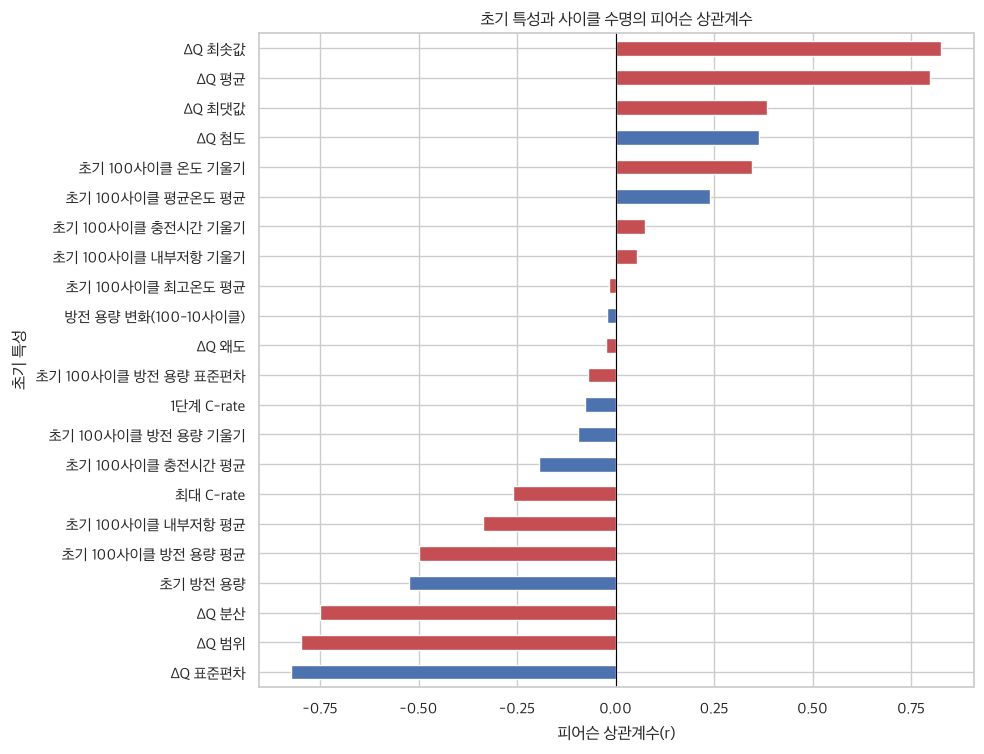

In [ ]:
numeric_features = feature_df.select_dtypes(include="number")
target_correlations = (
    numeric_features.corr(method="pearson")["cycle_life"]
    .drop("cycle_life")
    .dropna()
    .sort_values(key=np.abs, ascending=False)
)
display(target_correlations.rename("pearson_r").to_frame())

fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(target_correlations))))
colors = ["#C44E52" if value < 0 else "#4C72B0" for value in target_correlations]
target_corr_plot = target_correlations.sort_values()
target_corr_plot.index = [FEATURE_LABELS_KO.get(name, name) for name in target_corr_plot.index]
target_corr_plot.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("초기 특성과 사이클 수명의 피어슨 상관계수")
ax.set_xlabel("피어슨 상관계수(r)")
ax.set_ylabel("초기 특성")
plt.tight_layout()
save_figure("target_correlations.png")
plt.show()


### 7-2. 전체 특성 상관행렬

목표값을 포함한 숫자형 변수 쌍의 선형 상관을 색으로 표현한다. 진한 색 블록은 비슷한 정보를 반복해서 담는 특성 묶음일 수 있으며, 후속 모델에서 규제나 대표 특성 선택을 고려한다.


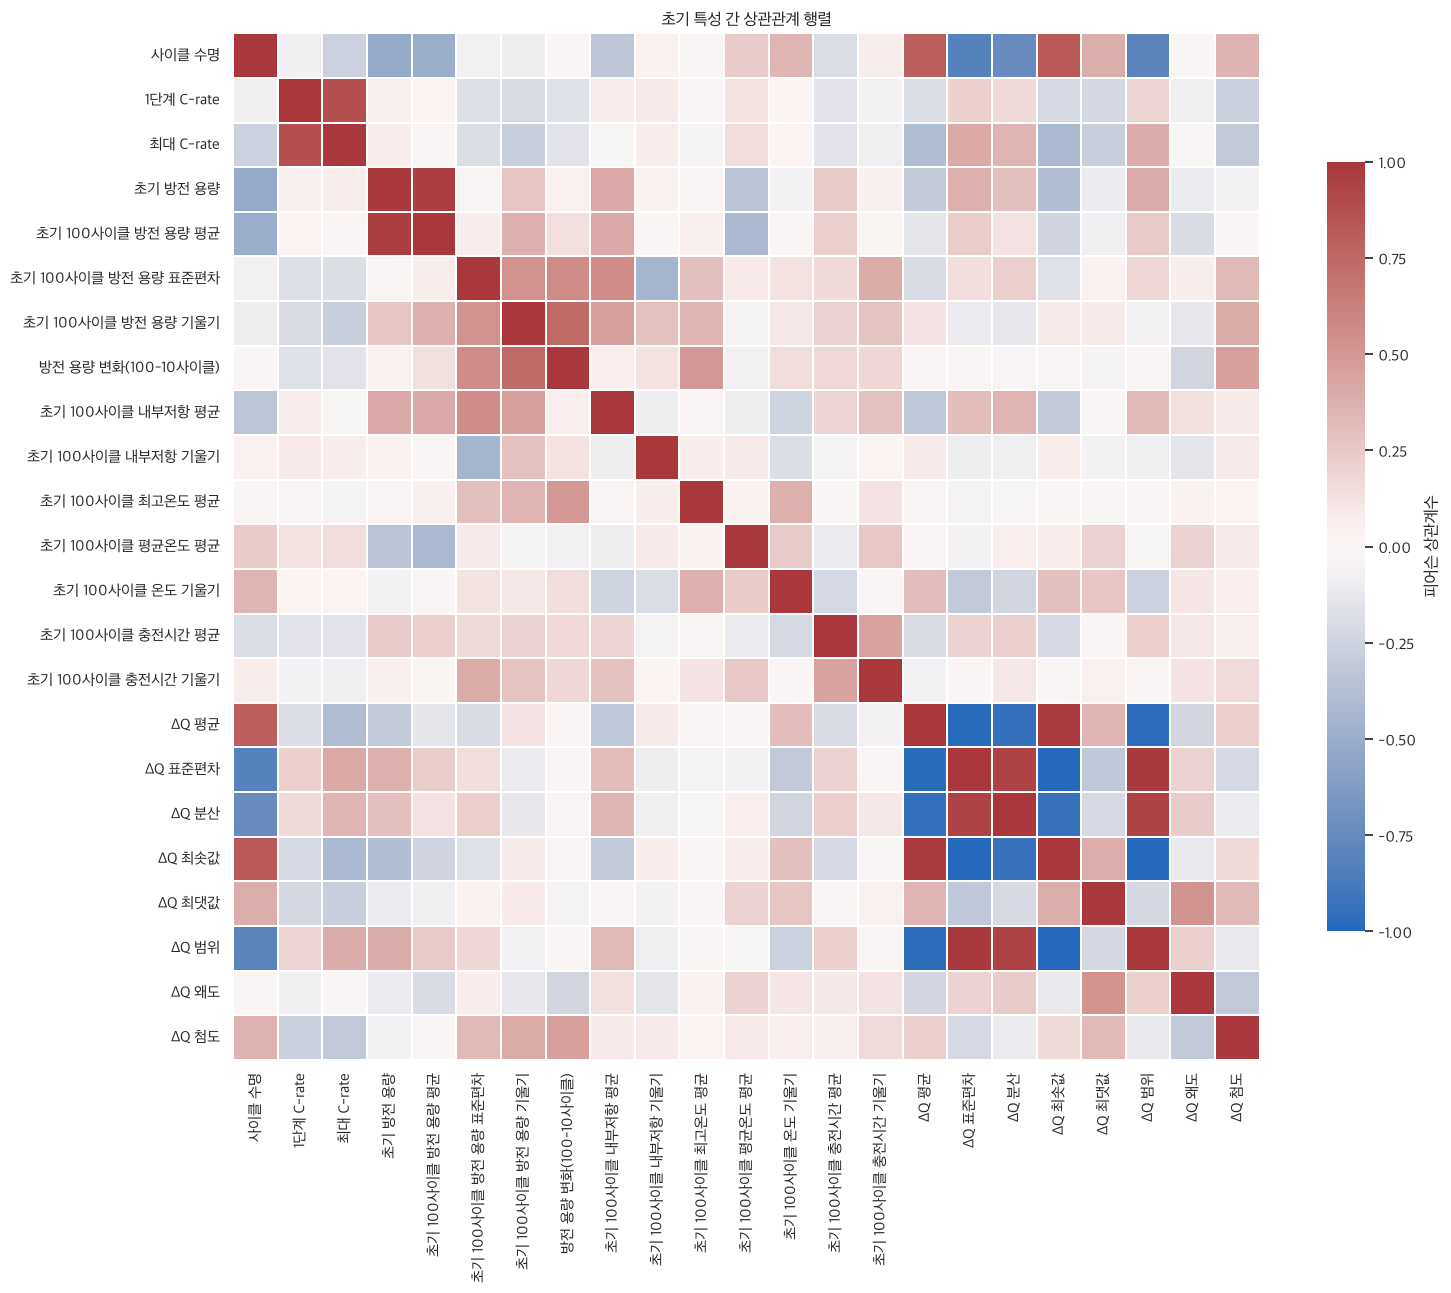

In [ ]:
corr_matrix = numeric_features.corr(method="pearson")
corr_matrix = corr_matrix.rename(index=FEATURE_LABELS_KO, columns=FEATURE_LABELS_KO)
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix, cmap="vlag", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.25, cbar_kws={"shrink": 0.75, "label": "피어슨 상관계수"}, ax=ax
)
ax.set_title("초기 특성 간 상관관계 행렬")
plt.tight_layout()
save_figure("feature_correlation_heatmap.png")
plt.show()


### 7-3. 고상관 특성 쌍 추출

목표값을 제외한 입력 특성 중 절대 상관계수가 0.80 이상인 조합을 표로 정리한다. 이 표와 VIF를 함께 사용하되, 높은 상관만으로 특성을 자동 삭제하지 않는다.


In [ ]:
feature_only_corr = numeric_features.drop(columns="cycle_life").corr().abs()
upper = feature_only_corr.where(np.triu(np.ones(feature_only_corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .rename("abs_correlation")
    .loc[lambda s: s >= 0.80]
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
display(high_corr_pairs)


,feature_1,feature_2,abs_correlation
0,dq_std,dq_min,0.9913
1,dq_std,dq_range,0.9898
2,dq_min,dq_range,0.9860
3,dq_mean,dq_std,0.9817
4,dq_mean,dq_min,0.9806
5,dq_mean,dq_range,0.9708
6,initial_QDischarge,QDischarge_mean_100,0.9667
7,dq_mean,dq_variance,0.9528
8,dq_variance,dq_range,0.9447
9,dq_std,dq_variance,0.9388


### VIF

VIF는 다른 입력 feature로 한 feature를 얼마나 잘 설명할 수 있는지 본다. 결측치는 이 진단에서만 중앙값으로 대치하고, 상수 feature는 제외한다. 통상 VIF 5 이상을 주의, 10 이상을 강한 다중공선성 후보로 보지만 기계적 삭제 기준으로 사용하지 않는다.

In [ ]:
vif_input = feature_df.select_dtypes(include="number").drop(columns="cycle_life")
vif_input = vif_input.dropna(axis=1, how="all")
vif_input = vif_input.loc[:, vif_input.nunique(dropna=True) > 1]
vif_input = vif_input.fillna(vif_input.median(numeric_only=True))

scaled = StandardScaler().fit_transform(vif_input)
vif_values = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i, column in enumerate(vif_input.columns):
        vif_values.append(variance_inflation_factor(scaled, i))

vif_df = pd.DataFrame({"feature": vif_input.columns, "VIF": vif_values})
vif_df["flag"] = pd.cut(
    vif_df["VIF"], bins=[-np.inf, 5, 10, np.inf],
    labels=["낮음", "주의", "강한 다중공선성 후보"]
)
display(vif_df.sort_values("VIF", ascending=False))


,feature,VIF,flag
19,dq_range,"1,000,799,917,193,443.5000",강한 다중공선성 후보
18,dq_max,"1,000,799,917,193,443.5000",강한 다중공선성 후보
17,dq_min,"1,000,799,917,193,443.5000",강한 다중공선성 후보
15,dq_std,324.8812,강한 다중공선성 후보
14,dq_mean,206.1261,강한 다중공선성 후보
3,QDischarge_mean_100,124.5521,강한 다중공선성 후보
2,initial_QDischarge,111.0951,강한 다중공선성 후보
16,dq_variance,25.9100,강한 다중공선성 후보
20,dq_skewness,9.5721,주의
1,max_c_rate,9.0605,주의


# 8. 모델 설계 전략 정리

### Feature Engineering

- 위 상관계수, 분포, 결측, VIF를 함께 보고 수명과 관계가 강한 **초기 100 cycle feature**를 선택한다.
- 서로 거의 같은 정보를 담는 feature가 많으면 Ridge/ElasticNet 또는 대표 feature 선택을 검토한다.
- ΔQ(V), QDischarge/IR/온도/chargetime slope, C-rate를 후보로 두되 batch와 protocol 효과를 함께 점검한다.
- knee point와 후기 slope는 전체 미래 구간을 사용하므로 초기 예측 모델에서 제외한다.

### Target

우선 문제는 regression으로 정의하며 target은 `cycle_life`이다. 분포가 심하게 오른쪽으로 치우쳤다면 `log(cycle_life)` 변환 전후의 잔차와 validation 성능을 비교한다. 예측값을 원 단위로 되돌릴 때 역변환 bias도 확인한다.

### Candidate Models

- Linear Regression: 해석 가능한 baseline
- Ridge: 공선성 완화 baseline
- ElasticNet: 규제와 feature 선택
- Random Forest: 비선형성과 상호작용 탐색
- Gradient Boosting; XGBoost가 없다면 `sklearn.ensemble.HistGradientBoostingRegressor`

모델 간 비교에서는 동일한 split과 metric(MAE, RMSE, R²)을 사용한다.

### Validation

표본 단위는 cycle 행이 아니라 **cell**이다. 동일 cell의 cycle이 train/test에 동시에 들어가면 심각한 leakage가 발생하므로, 반드시 cell 단위 feature table을 만든 뒤 분할한다.

- 기본: cell 단위 train/validation/test 또는 K-fold
- 동일 protocol의 반복 셀이 강하게 묶이면 group-aware split도 검토
- batch 차이가 강하면 random split만 보고 일반화 성능을 판단하지 말고, `LeaveOneGroupOut(groups=batch)` 같은 **batch 기반 외부 검증**을 함께 고려
- 전처리, 결측치 대치, scaling, feature 선택은 각 training fold 안에서만 학습하도록 Pipeline 사용

### 다음 단계 체크리스트

1. cycle 1의 0값이 placeholder인지 실험 문서로 확인한다.
2. IQR 이상치 후보의 protocol/원시 곡선을 검토한다.
3. ΔQ(V) 계산 실패 셀이 없는지 확인한다.
4. batch-aware baseline과 random-split baseline의 성능 차이를 비교한다.
5. 최종 모델은 성능뿐 아니라 fold별 안정성과 feature 해석의 일관성을 함께 보고 선택한다.